# **Install Package**

In [ ]:
install.packages("tseries", dependencies = TRUE, repos = "http://cran.us.r-project.org")
install.packages("forecast", dependencies = TRUE, repos = "http://cran.us.r-project.org")
install.packages("nortest")
install.packages("TSA")
install.packages("e1071")
install.packages("caret")
install.packages("Metrics")
install.packages("ggplot2")
install.packages("kernlab")
install.packages("readxl", dependencies = TRUE, repos = "http://cran.us.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘x13binary’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’, ‘forecTheta’, ‘rticles’, ‘seasonal’, ‘uroot’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘leaps’, ‘locfit’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’,

In [ ]:
#Import library
library(readxl)
library(tseries)
library(forecast)
library(lmtest)
library(nortest)
library(TTR)
library(TSA)
library(MASS)
library(graphics)
library(dplyr)
library(e1071)
library(scales)
library(caret)
library(Metrics)
library(ggplot2)
library(kernlab)


Attaching package: ‘kernlab’


The following object is masked from ‘package:ggplot2’:

    alpha


The following object is masked from ‘package:scales’:

    alpha




# **Preprocessing Data**

In [ ]:
#Input data
df <- read_excel("Data Historis MYOR.xlsx")
head(df)

Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
2020-01-02,2030,2050,2050,2000,"1,55M",-0.0098
2020-01-03,2030,2030,2040,2020,"2,58M",0.0000
2020-01-06,2020,2030,2040,2000,"1,18M",-0.0049
2020-01-07,2030,2020,2040,2020,"1,41M",0.0050
2020-01-08,2000,2030,2030,1985,"2,45M",-0.0148
2020-01-09,2080,2000,2080,2000,"6,37M",0.0400


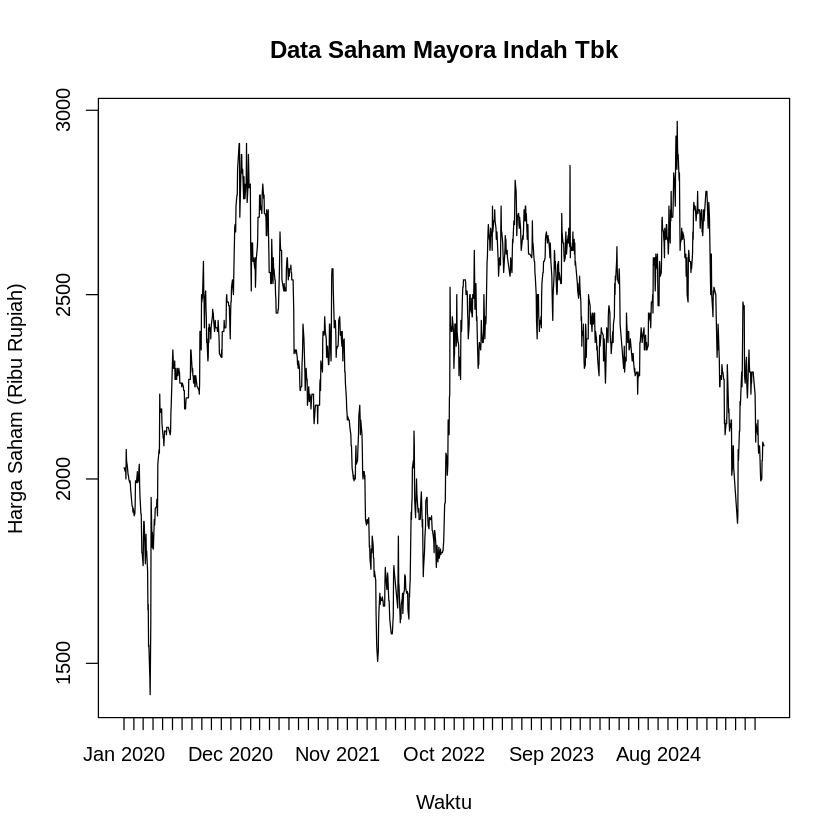

In [ ]:
tanggal <- as.Date(df$Tanggal)
data <- df$Terakhir  # gunakan kolom 'Terakhir' untuk harga

# Plot
plot(tanggal, data, type = "l",
     main = "Data Saham Mayora Indah Tbk",
     xlab = "Waktu",
     ylab = "Harga Saham (Ribu Rupiah)",
     xaxt = "n")

# Tambahkan sumbu X dengan format bulan-tahun
axis.Date(1, at = seq(min(tanggal), max(tanggal), by = "month"), format = "%b %Y")

In [ ]:
# Jumlah total data
n <- length(data)

# Hitung jumlah train dan test
n_test <- 21                    #Mewakili kurang lebih satu bulan dalam bursa saham
n_train <- n - n_test

# Partisi data
train <- data[1:n_train]
test <- data[(n_train + 1):n]

# Cek panjang
length(train)
length(test)


[1] 1299

[1] 21

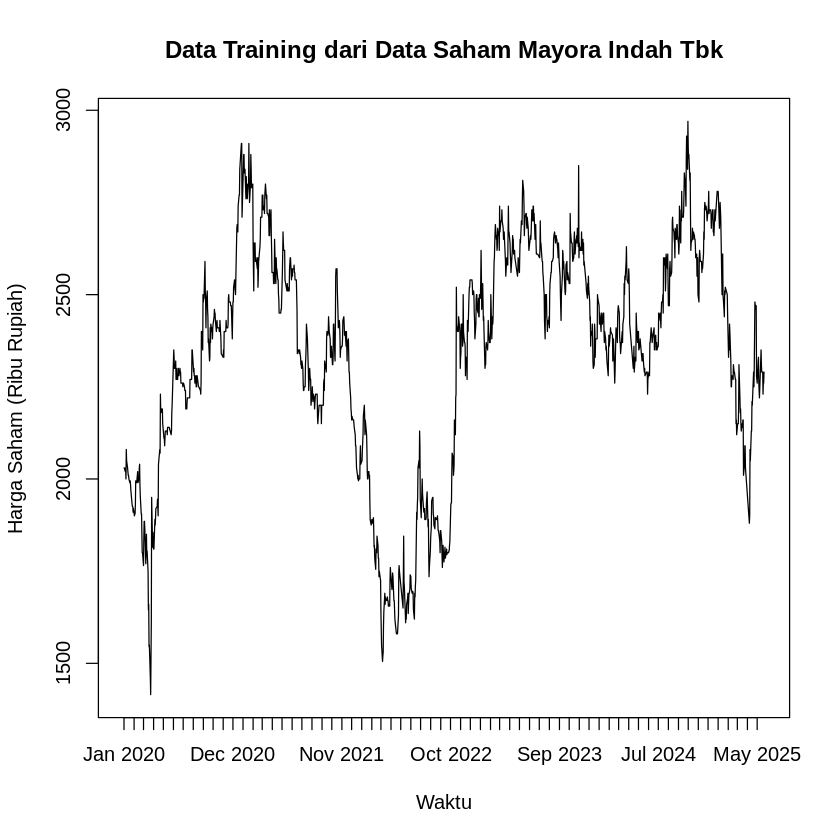

In [ ]:
# Ambil tanggal yang sesuai dengan data train
tanggal_train <- tanggal[1:length(train)]

# Plot
plot(tanggal_train, train, type = "l",
     main = "Data Training dari Data Saham Mayora Indah Tbk",
     xlab = "Waktu",
     ylab = "Harga Saham (Ribu Rupiah)",
     xaxt = "n")

# Sumbu X: bulan-tahun
axis.Date(1, at = seq(min(tanggal_train), max(tanggal_train), by = "month"), format = "%b %Y")

# **Stasioneritas**

lambda,lik
2,-2000.681


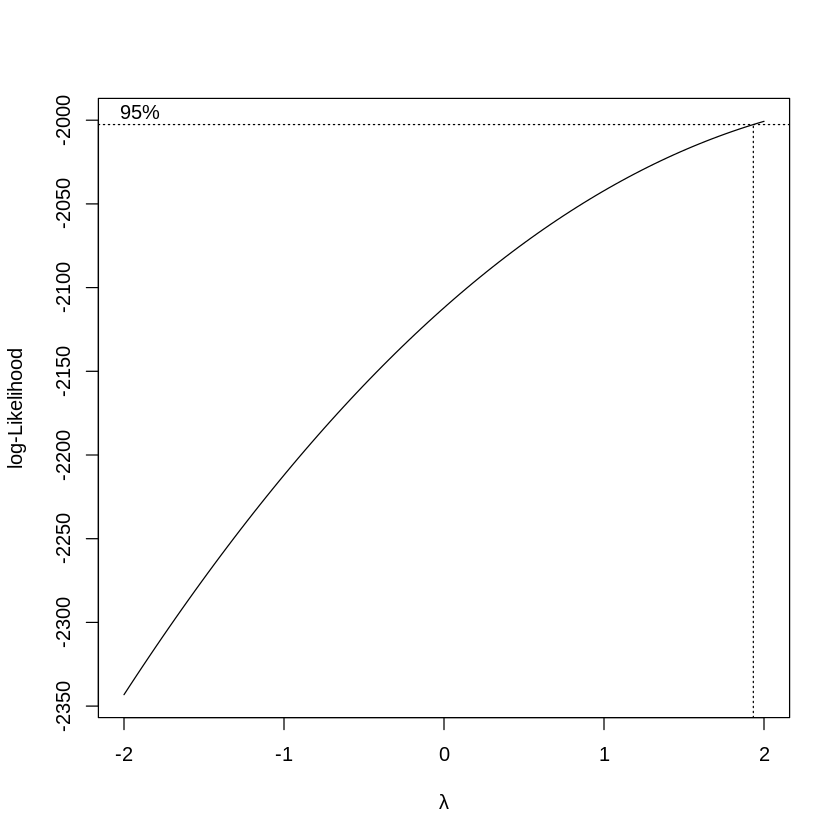

In [ ]:
#Uji Stationeritas Variansi
b <- boxcox(train~1)
#Nilai Rounded Lambda
lambda <- b$x
lik <- b$y
bc <- cbind(lambda, lik)
sorted_bc <- bc[order(-lik),]
head(sorted_bc, n=1)

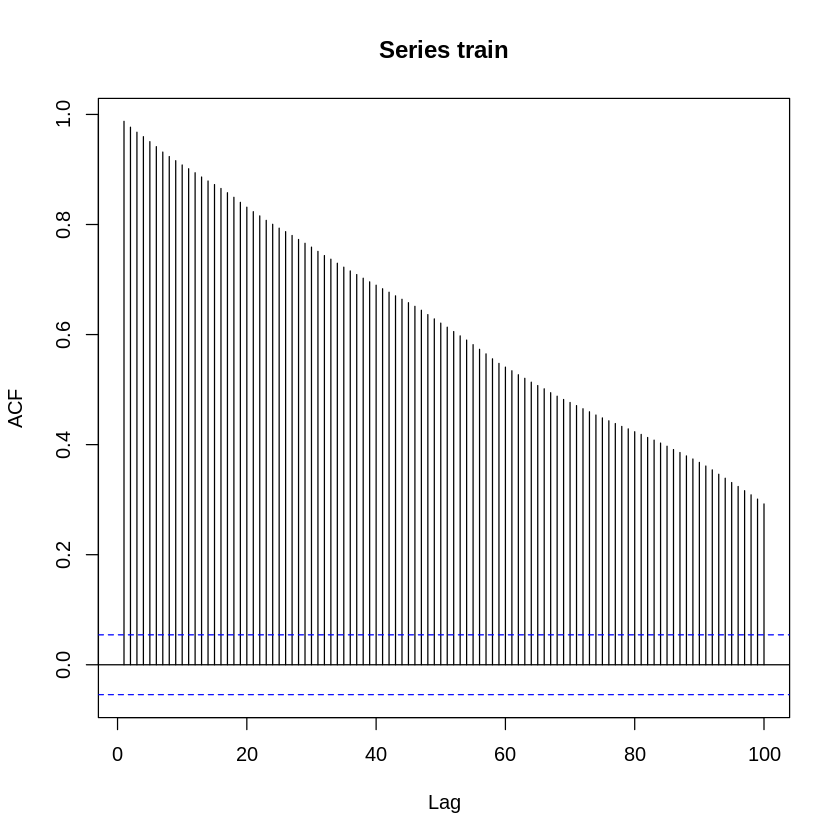

In [ ]:
#ACF
acf(train, lag.max=100)     # ACF masih menurun secara perlahan

In [ ]:
#Uji ADF
adf.test(train)     # p-value > 0.05 menunjukkan data belum stasioner terhadap rata-rata


	Augmented Dickey-Fuller Test

data:  train
Dickey-Fuller = -2.2232, Lag order = 10, p-value = 0.4838
alternative hypothesis: stationary


In [ ]:
#Diferensiasi
diff(train)

[1]    0  -10   10  -30   80  -30  -20  -10  -10    0  -10  -10    5  -10
  [15]  -15  -10  -30   -5    0  -15   10  -20    5    0   25   65   -5   10
  [29]   10   10  -30   10   30   10  -55  -30  -50    0  -55  -50    0  -35
  [43]   75   45    0  -20  -95   30   50  -55   10  -55 -105   15 -115    5
  [57]  -90  -45  195  340 -135   40  -25  -20    0   80  -15   20   25    5
  [71]   20  -20  -25  140   30   10  -10  160  -50   10  -10   10  -40  -40
  [85]    0  -20   40    0    0    0  -10   20    0    0    0  -20   10   50
  [99]   20  120   30  -20  -30    0   20  -50   30  -30    0   30    0  -10
 [113]  -10   20  -10    0  -30    0    0    0  -10   10    0  -10  -10    0
 [127]    0  -50    0   20   10    0    0    0    0    0   50    0    0    0
 [141]   80    0  -60   10  -20    0  -20   20  -30    0   30    0  -30    0
 [155]  -10  -10   30  140    0  -50  150  -20   10    0  100  -80  -30  -70
 [169]   70   30  -50  -20  -70   10  -60   10   80  -40   50  -20   10  -30
 [183]   30   10   20   20  -10    0  -20  -30   20   10  -20    0    0    0
 [197]  -10    0   30  -50  -40  -10   20  -20   70    0    0    0   30  -20
 [211]    0    0   10   70   10  -20    0    0  -10    0    0  -90   60   40
 [225]    0   40   20  -20  -20   50  130   10  -10  -10   70   30    0   70
 [239]   70    0 -200  170    0  -50   10    0  -80   60  -50   30  -40   40
 [253]    0  110  -90  -70   50   80  -40  -50    0   10 -160  -70  -60  130
 [267]    0  -50   10    0  -30   30  -80   30   40   30   10   20   60    0
 [281]    0   60  -20   20  -40   10  -20   50   30  -40   10  -50    0    0
 [295]  -10  -50   70  -70   40   30  -70  -40  -60    0  -30    0    0  120
 [309] -110  -10   70  -30    0  -30    0  -40  -10  -40    0    0    0   10
 [323]    0  100   50   60  -30  -20    0  -80  -30   20  -20   10  -10    0
 [337]   60   30    0  -60   30  -20   20    0   10  -20    0  -20    0    0
 [351]  -40  -40 -120   10    0    0  -10   10  -20  -20    0  -10   20  -20
 [365]  -40  -20    0   10    0   60   20   30   60  -40  -60  -30  -50   60
 [379]  -20  -10    0  -70   30   20  -20  -20   20  -10  -30   30   10    0
 [393]    0  -60  -20   40   10    0    0    0    0  -50   50    0    0    0
 [407]   60   10  -30   80  -20    0  -10   90   20  -10   10   40  -20  -20
 [421]  -20  -50    0   30    0  -50    0   20   90    0  -80  -20  100  130
 [435]   20    0  -60  -60  -40   20  -10  -30  -60   20   10    0    0   20
 [449]   50   10  -20  -30    0   10  -40   40  -40  -40   50   10  -40  -50
 [463]    0  -30  -40  -30  -10  -20   10  -10    0    0  -10  -10  -20  -30
 [477]    0  -30  -30  -20  -10   10  -15    5    0   60   30  -50   10   30
 [491]   20   20   50   30  -30  -50   40  -10  -30  -40  -60  -20   20    0
 [505]  -20   10  -70  -50  -15   15  -10    0   15  -35  -45    5  -35  -30
 [519]   55    0  -10   45  -25  -35    0  -50   15  -25  -85  -90  -45   15
 [533]   10   75   35   50  -30   20  -10    5   -5   10  -10    0  -15    5
 [547]   -5   70   35  -15  -35  -10   15   30  -10  -65    0  -25  -25  -35
 [561]   -5    0    0    0   50  120   15  -15 -100   90  105 -125  -10 -100
 [575]   30  -20   40   15   15  -55   50   15   40   -5  -30  -15    0    5
 [589]   -5  -45  -25   70  -10   30   15  185  -20   40   20   80   20  -20
 [603]  100  -40 -145  -50   45   30   30  -40  -40  -10    0   10  -30    0
 [617]    5   40   15   15  -95   20  -90  -65   25   45   35   15   15   70
 [631]   10    0  -45   -5  -25  -10   30    0   -5    0   10  -20  -20    0
 [645]  -20  -10  -30   60    0  -30  -40  -30   30   30  -45   25   -5   20
 [659]  -30   15   10  -15    5    0    0    5    0   15   10  100    5    0
 [673]   85   50  -10  -50   10   20  120  -40  100   10  290 -100  -20    0
 [687]    0   40  -10  -30 -100   30   10   80    0  -60   10  130 -100  -30
 [701]    0  -10  -80   50    0  -60  160  -10  -20  100   20    0   20    0
 [715]    0    0    0  -10  -30   10  -10  -50  -20  -50   40   70   10    0

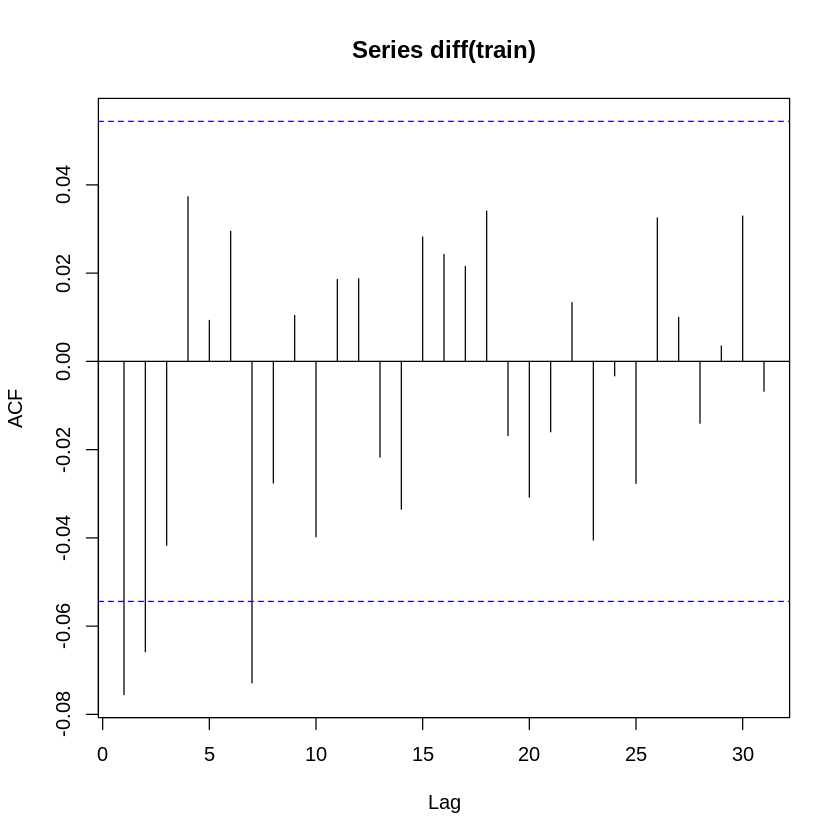

In [ ]:
#ACF Diferensiasi
acf(diff(train))    # ACF tidak lagi menurun secara perlahan

In [ ]:
#Uji ADF Diferensiasi
adf.test(diff(train))     # p-value < 0.05 menunjukkan data sudah stasioner terhadap rata-rata

Warning message in adf.test(diff(train)):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  diff(train)
Dickey-Fuller = -11.914, Lag order = 10, p-value = 0.01
alternative hypothesis: stationary


# **ARIMA**

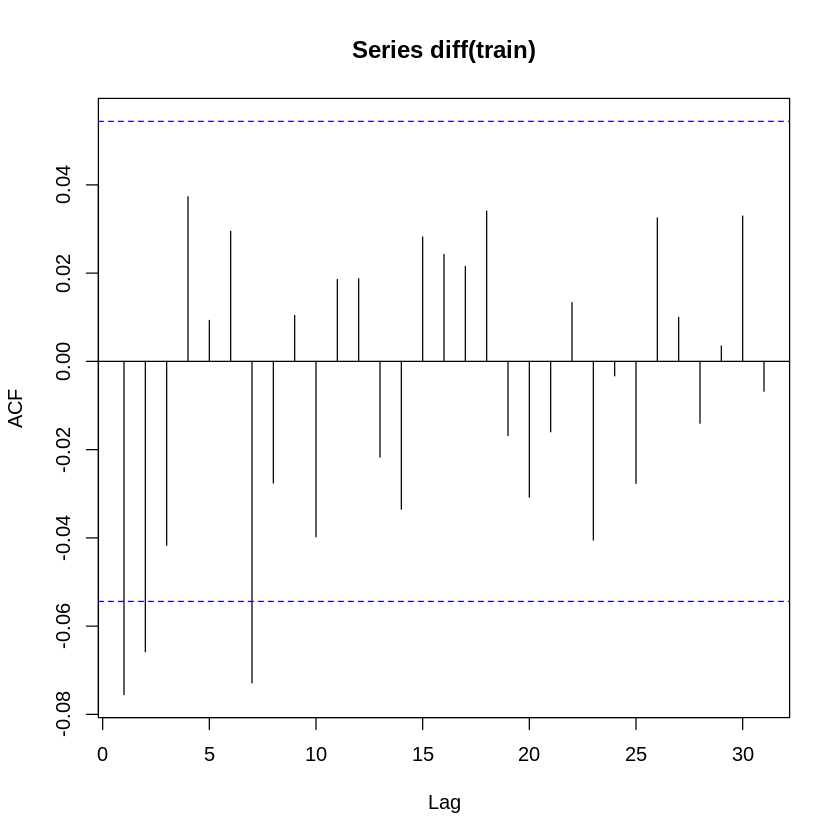

In [ ]:
#Identifikasi Orde
acf(diff(train))

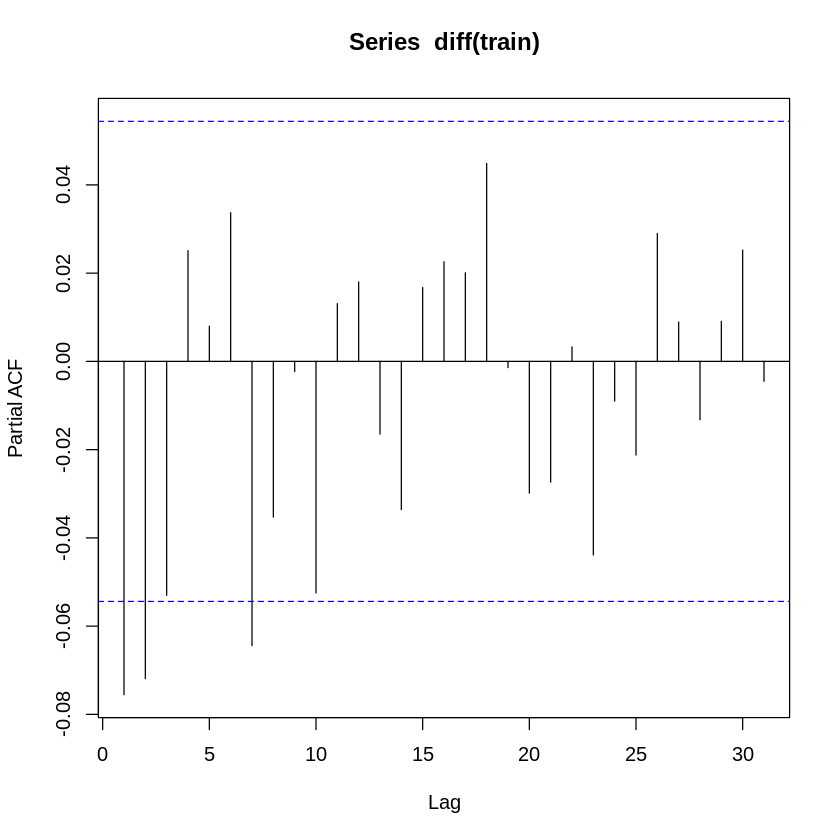

In [ ]:
pacf(diff(train))

**Uji Signifikansi**

In [ ]:
# ARIMA(0,1,1)
cat("\n=== Uji Signifikansi ARIMA(0,1,1) ===\n")
model_011 <- Arima(train, order = c(0,1,1), include.mean = FALSE)
coeftest(model_011)

# ARIMA(0,1,2)
cat("\n=== Uji Signifikansi ARIMA(0,1,2) ===\n")
model_012 <- Arima(train, order = c(0,1,2), include.mean = FALSE)
coeftest(model_012)

# ARIMA(1,1,0)
cat("\n=== Uji Signifikansi ARIMA(1,1,0) ===\n")
model_110 <- Arima(train, order = c(1,1,0), include.mean = FALSE)
coeftest(model_110)

# ARIMA(1,1,1)
cat("\n=== Uji Signifikansi ARIMA(1,1,1) ===\n")
model_111 <- Arima(train, order = c(1,1,1), include.mean = FALSE)
coeftest(model_111)

# ARIMA(1,1,2)
cat("\n=== Uji Signifikansi ARIMA(1,1,2) ===\n")
model_112 <- Arima(train, order = c(1,1,2), include.mean = FALSE)
coeftest(model_112)

# ARIMA(2,1,0)
cat("\n=== Uji Signifikansi ARIMA(2,1,0) ===\n")
model_210 <- Arima(train, order = c(2,1,0), include.mean = FALSE)
coeftest(model_210)

# ARIMA(2,1,1)
cat("\n=== Uji Signifikansi ARIMA(2,1,1) ===\n")
model_211 <- Arima(train, order = c(2,1,1), include.mean = FALSE)
coeftest(model_211)

# ARIMA(2,1,2)
cat("\n=== Uji Signifikansi ARIMA(2,1,2) ===\n")
model_212 <- Arima(train, order = c(2,1,2), include.mean = FALSE)
coeftest(model_212)


=== Uji Signifikansi ARIMA(0,1,1) ===



z test of coefficients:

     Estimate Std. Error z value Pr(>|z|)   
ma1 -0.088609   0.029998 -2.9538 0.003139 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



=== Uji Signifikansi ARIMA(0,1,2) ===



z test of coefficients:

     Estimate Std. Error z value Pr(>|z|)   
ma1 -0.086960   0.027586 -3.1523  0.00162 **
ma2 -0.067379   0.026592 -2.5338  0.01128 * 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



=== Uji Signifikansi ARIMA(1,1,0) ===


...


z test of coefficients:

     Estimate Std. Error z value Pr(>|z|)   
ar1 -0.080901   0.027682 -2.9225 0.003472 **
ar2 -0.071816   0.027670 -2.5955 0.009445 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



=== Uji Signifikansi ARIMA(2,1,1) ===



z test of coefficients:

     Estimate Std. Error z value Pr(>|z|)
ar1  0.253642   0.236853  1.0709   0.2842
ar2 -0.051298   0.036942 -1.3886   0.1649
ma1 -0.337071   0.236348 -1.4262   0.1538



=== Uji Signifikansi ARIMA(2,1,2) ===



z test of coefficients:

    Estimate Std. Error z value  Pr(>|z|)    
ar1  0.84971    0.11701  7.2618 3.819e-13 ***
ar2 -0.75070    0.11576 -6.4848 8.887e-11 ***
ma1 -0.91786    0.11641 -7.8846 3.156e-15 ***
ma2  0.73959    0.12136  6.0940 1.101e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


**Uji Autokorelasi**


	Ljung-Box test

data:  Residuals from ARIMA(0,1,1)
Q* = 21.966, df = 9, p-value = 0.008986

Model df: 1.   Total lags used: 10



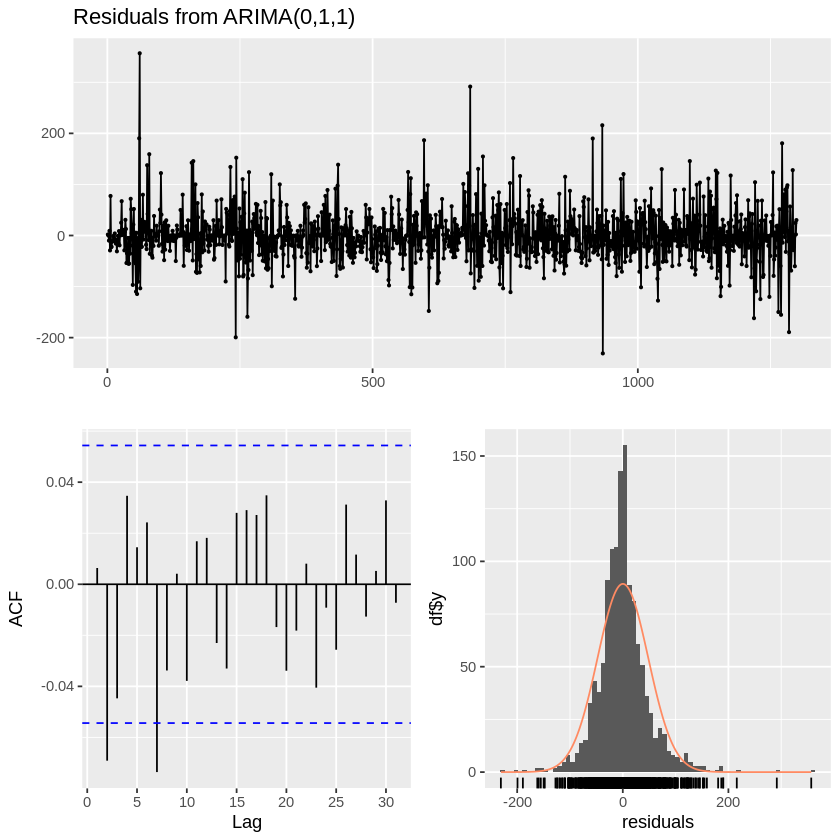


	Ljung-Box test

data:  Residuals from ARIMA(0,1,2)
Q* = 15.1, df = 8, p-value = 0.05724

Model df: 2.   Total lags used: 10



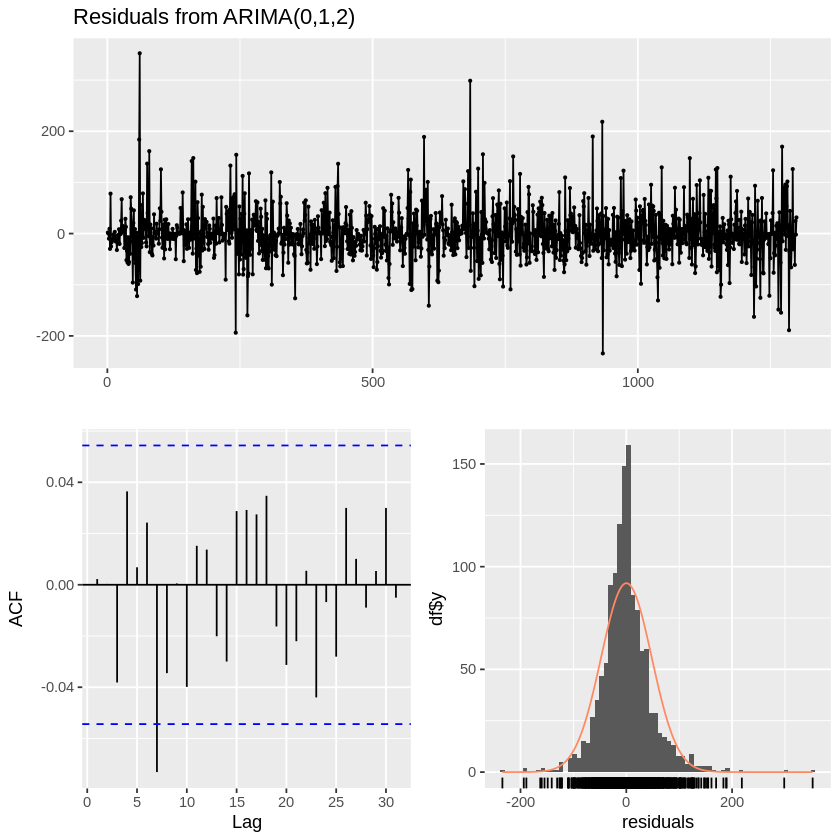


	Ljung-Box test

data:  Residuals from ARIMA(1,1,0)
Q* = 23.15, df = 9, p-value = 0.005868

Model df: 1.   Total lags used: 10



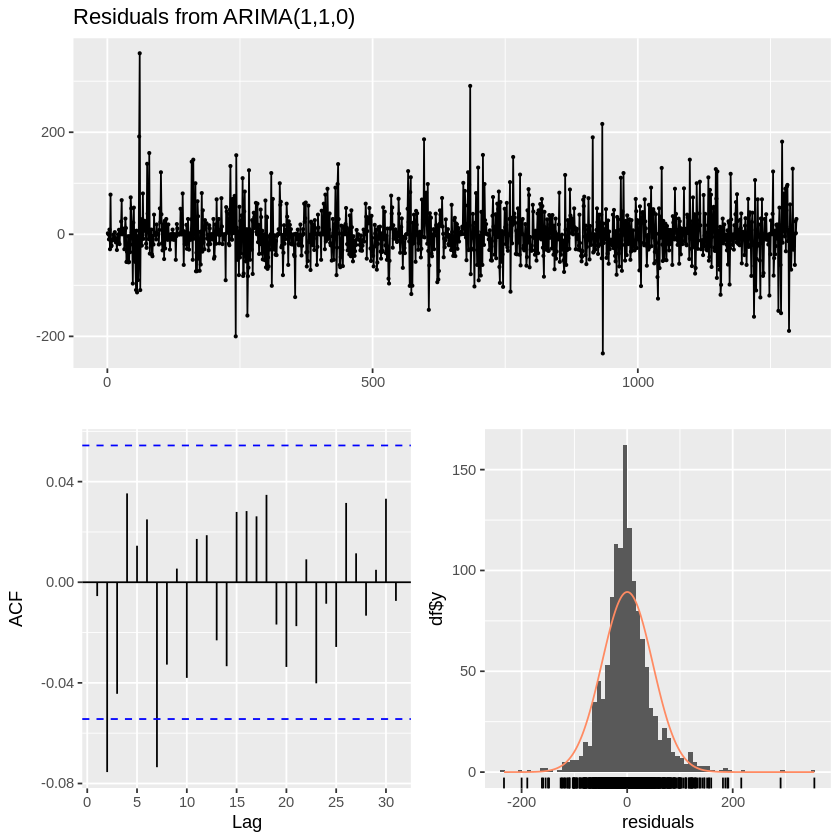


	Ljung-Box test

data:  Residuals from ARIMA(1,1,1)
Q* = 15.314, df = 8, p-value = 0.05332

Model df: 2.   Total lags used: 10



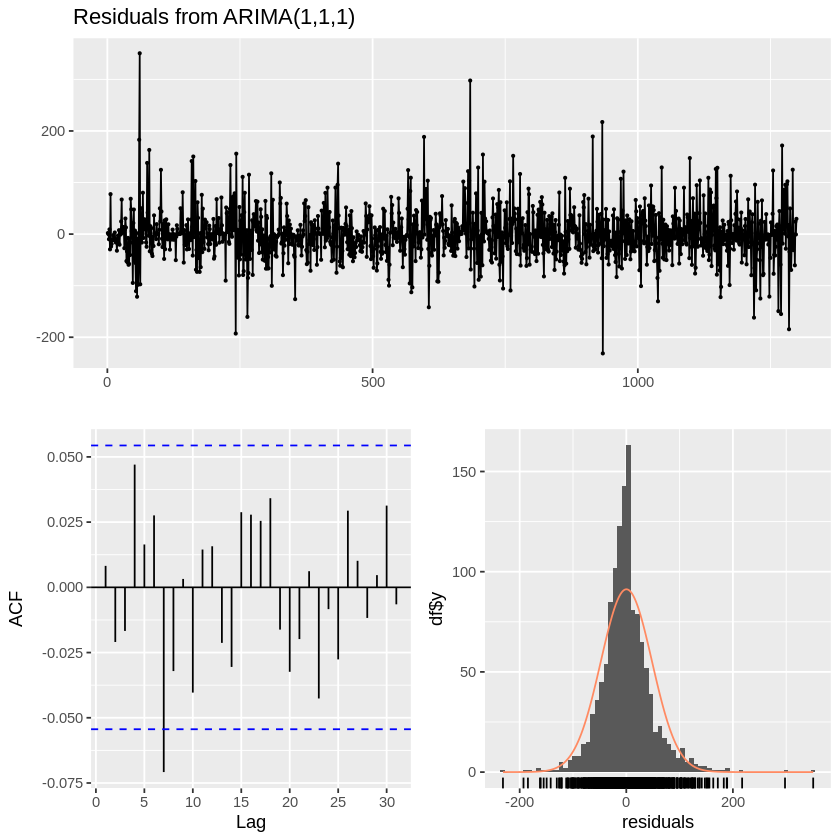


	Ljung-Box test

data:  Residuals from ARIMA(1,1,2)
Q* = 14.351, df = 7, p-value = 0.04527

Model df: 3.   Total lags used: 10



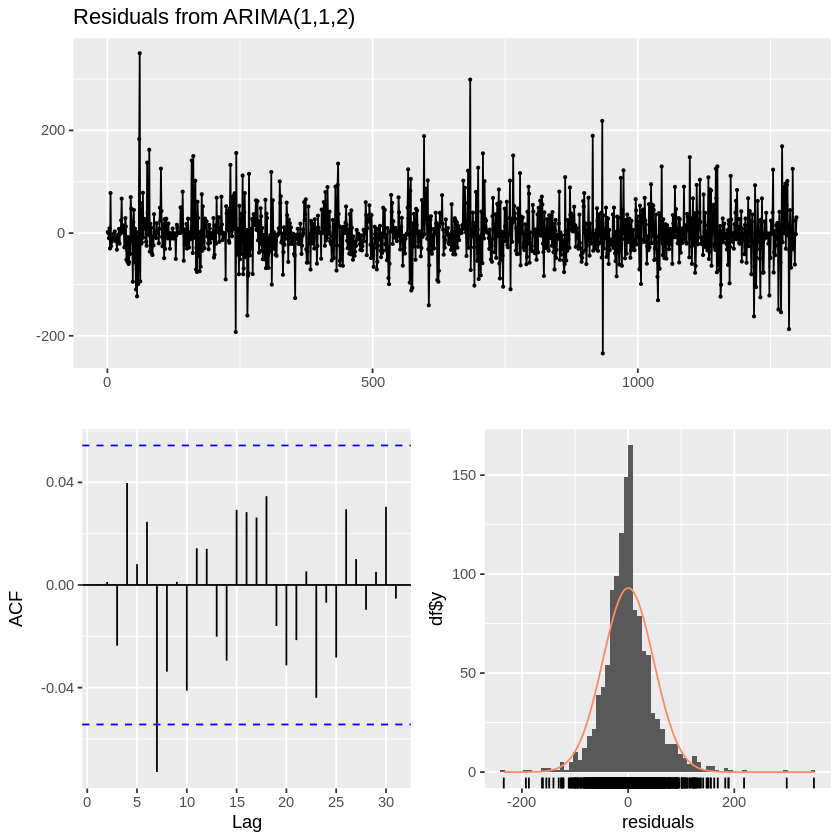


	Ljung-Box test

data:  Residuals from ARIMA(2,1,0)
Q* = 16.055, df = 8, p-value = 0.0416

Model df: 2.   Total lags used: 10



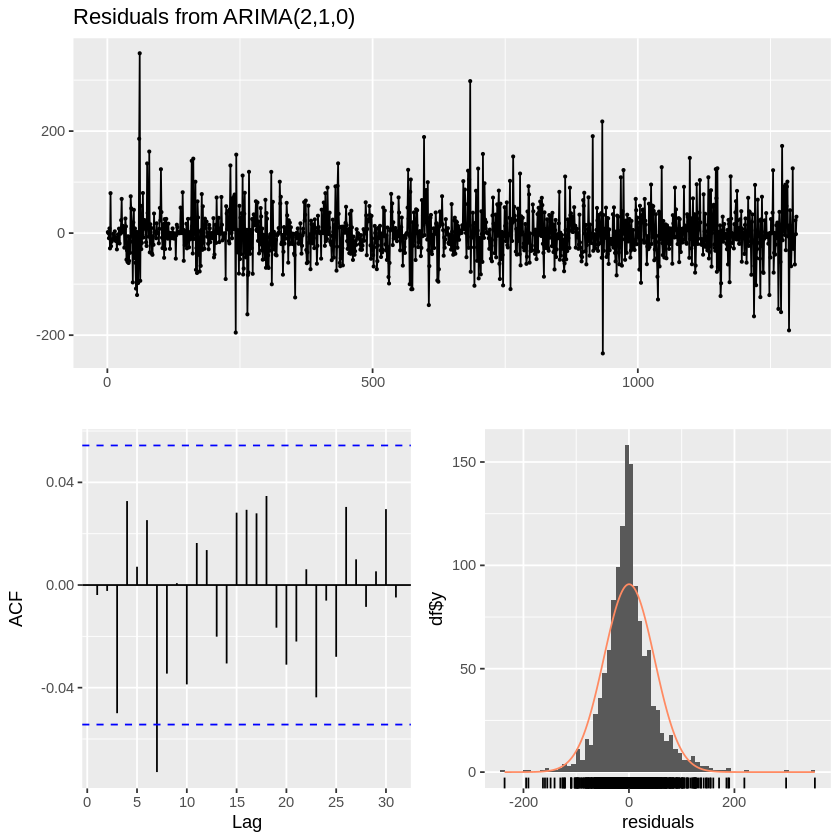


	Ljung-Box test

data:  Residuals from ARIMA(2,1,1)
Q* = 14.125, df = 7, p-value = 0.04901

Model df: 3.   Total lags used: 10



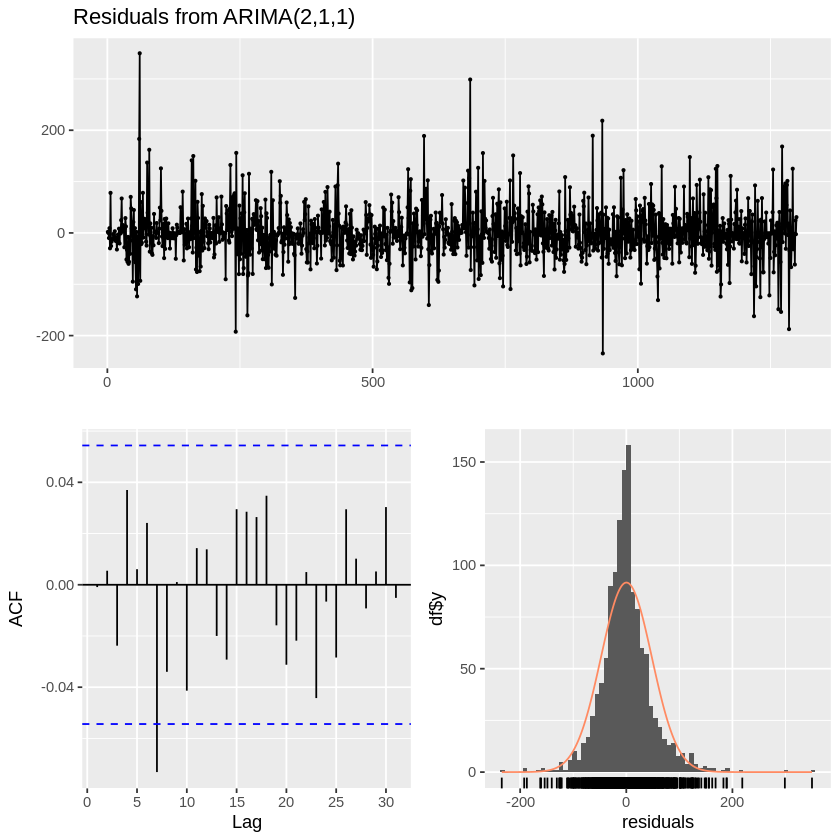


	Ljung-Box test

data:  Residuals from ARIMA(2,1,2)
Q* = 11.208, df = 6, p-value = 0.08216

Model df: 4.   Total lags used: 10



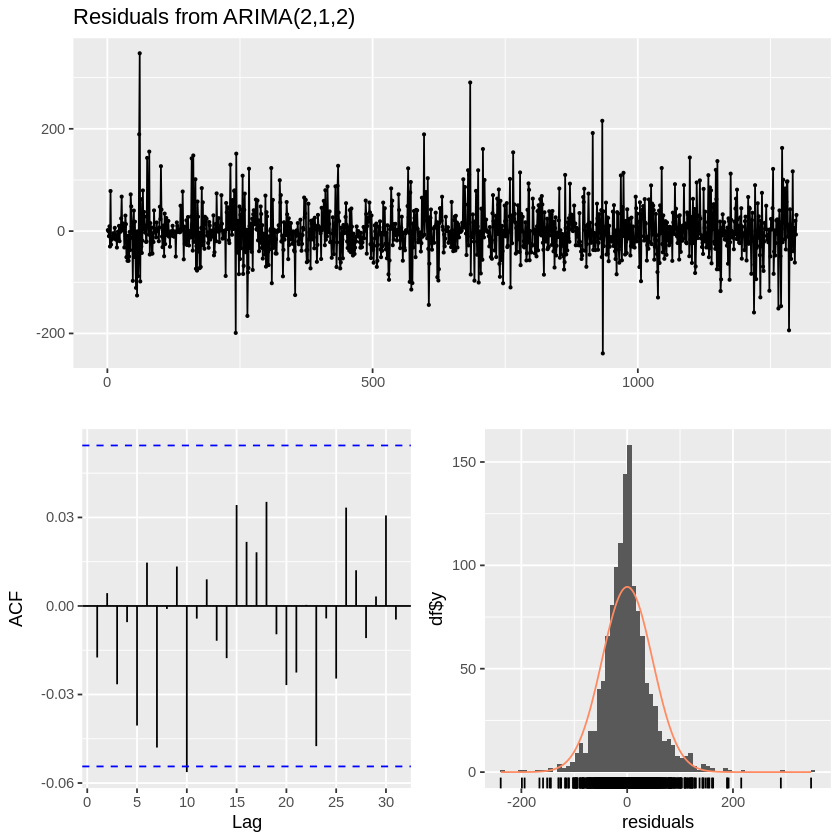

In [ ]:
#Uji Sisaan
#Asumsi Non Autokorelasi
checkresiduals(model_011)
checkresiduals(model_012)
checkresiduals(model_110)
checkresiduals(model_111)
checkresiduals(model_112)
checkresiduals(model_210)
checkresiduals(model_211)
checkresiduals(model_212)

**Uji Normalitas**

In [ ]:
# ARIMA(0,1,1)
cat("\n=== Uji Normalitas Residu ARIMA(0,1,1) ===\n")
model_011 <- Arima(train, order = c(0,1,1), include.mean = FALSE)
print(lillie.test(residuals(model_011)))

# ARIMA(0,1,2)
cat("\n=== Uji Normalitas Residu ARIMA(0,1,2) ===\n")
model_012 <- Arima(train, order = c(0,1,2), include.mean = FALSE)
print(lillie.test(residuals(model_012)))

# ARIMA(1,1,0)
cat("\n=== Uji Normalitas Residu ARIMA(1,1,0) ===\n")
model_110 <- Arima(train, order = c(1,1,0), include.mean = FALSE)
print(lillie.test(residuals(model_110)))

# ARIMA(1,1,1)
cat("\n=== Uji Normalitas Residu ARIMA(1,1,1) ===\n")
model_111 <- Arima(train, order = c(1,1,1), include.mean = FALSE)
print(lillie.test(residuals(model_111)))

# ARIMA(1,1,2)
cat("\n=== Uji Normalitas Residu ARIMA(1,1,2) ===\n")
model_112 <- Arima(train, order = c(1,1,2), include.mean = FALSE)
print(lillie.test(residuals(model_112)))

# ARIMA(2,1,0)
cat("\n=== Uji Normalitas Residu ARIMA(2,1,0) ===\n")
model_210 <- Arima(train, order = c(2,1,0), include.mean = FALSE)
print(lillie.test(residuals(model_210)))

# ARIMA(2,1,1)
cat("\n=== Uji Normalitas Residu ARIMA(2,1,1) ===\n")
model_211 <- Arima(train, order = c(2,1,1), include.mean = FALSE)
print(lillie.test(residuals(model_211)))

# ARIMA(2,1,2)
cat("\n=== Uji Normalitas Residu ARIMA(2,1,2) ===\n")
model_212 <- Arima(train, order = c(2,1,2), include.mean = FALSE)
print(lillie.test(residuals(model_212)))


=== Uji Normalitas Residu ARIMA(0,1,1) ===

	Lilliefors (Kolmogorov-Smirnov) normality test

data:  residuals(model_011)
D = 0.0898, p-value < 2.2e-16


=== Uji Normalitas Residu ARIMA(0,1,2) ===

	Lilliefors (Kolmogorov-Smirnov) normality test

data:  residuals(model_012)
D = 0.092266, p-value < 2.2e-16


=== Uji Normalitas Residu ARIMA(1,1,0) ===

	Lilliefors (Kolmogorov-Smirnov) normality test

data:  residuals(model_110)
D = 0.090767, p-value < 2.2e-16


=== Uji Normalitas Residu ARIMA(1,1,1) ===

	Lilliefors (Kolmogorov-Smirnov) normality test

data:  residuals(model_111)
D = 0.089089, p-value < 2.2e-16


=== Uji Normalitas Residu ARIMA(1,1,2) ===

	Lilliefors (Kolmogorov-Smirnov) normality test

data:  residuals(model_112)
D = 0.092386, p-value < 2.2e-16


=== Uji Normalitas Residu ARIMA(2,1,0) ===

	Lilliefors (Kolmogorov-Smirnov) normality test

data:  residuals(model_210)
D = 0.091825, p-value < 2.2e-16


=== Uji Normalitas Residu ARIMA(2,1,1) ===

	Lilliefors (Kolmogorov-Smi

**Model yang signifikan dan memenuhi asumsi nonautokorelasi** : ARIMA (0,1,2), ARIMA (1,1,1), ARIMA (2,1,2)

In [ ]:
# Hitung dugaan (fitted values) dari model ARIMA (0,1,2) dan tampilkan bersama data asli
arima1 <- Arima(train, order = c(0,1,2), include.mean = TRUE, method="ML")
dugaan1 <- fitted(arima1)
print(cbind(train, dugaan1))

# Hitung dugaan (fitted values) dari model ARIMA (1,1,1) dan tampilkan bersama data asli
arima2 <- Arima(train, order = c(1,1,1), include.mean = TRUE, method="ML")
dugaan2 <- fitted(arima2)
print(cbind(train, dugaan2))

# Hitung dugaan (fitted values) dari model ARIMA (2,1,2) dan tampilkan bersama data asli
arima3 <- Arima(train, order = c(2,1,2), include.mean = TRUE, method="ML")
dugaan3 <- fitted(arima3)
print(cbind(train, dugaan3))


Time Series:
Start = 1 
End = 1299 
Frequency = 1 
     train  dugaan1
   1  2030 2027.970
   2  2030 2030.000
   3  2020 2029.972
   4  2030 2020.861
   5  2000 2029.875
   6  2080 2001.982
   7  2050 2075.229
   8  2030 2046.936
   9  2020 2033.173
  10  2010 2022.287
  11  2010 2011.956
  12  2000 2010.998
  13  1990 2001.088
  14  1995 1991.705
  15  1985 1995.461
  16  1970 1985.688
  17  1960 1972.069
  18  1930 1962.107
  19  1925 1933.605
  20  1925 1927.912
  21  1910 1925.833
  22  1920 1911.573
  23  1900 1920.334
  24  1905 1901.200
  25  1905 1906.040
  26  1930 1904.834
  27  1995 1927.882
  28  1990 1987.467
  29  2000 1985.257
  30  2010 1998.547
  31  2020 2008.010
  32  1990 2018.186
  33  2000 1991.643
  34  2030 2001.173
  35  2040 2026.930
  36  1985 2036.921
  37  1955 1988.634
  38  1905 1961.424
  39  1905 1912.173
  40  1850 1909.426
  41  1800 1855.651
  42  1800 1808.844
  43  1765 1804.520
  44  1840 1769.033
  45  1885 1836.492
  46  1885 1875.999
  47  186

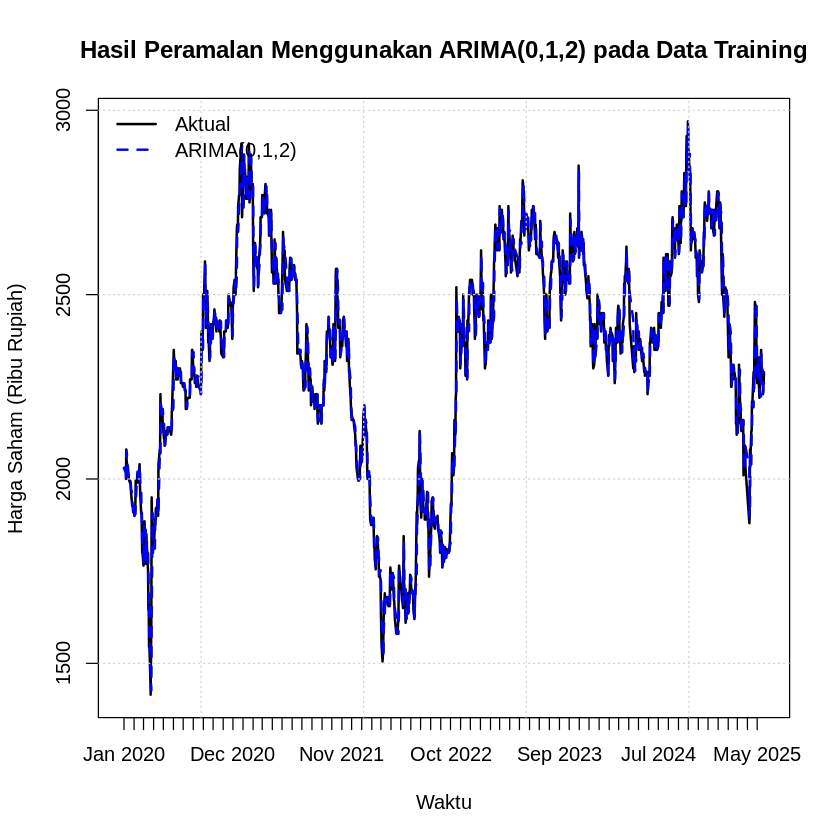

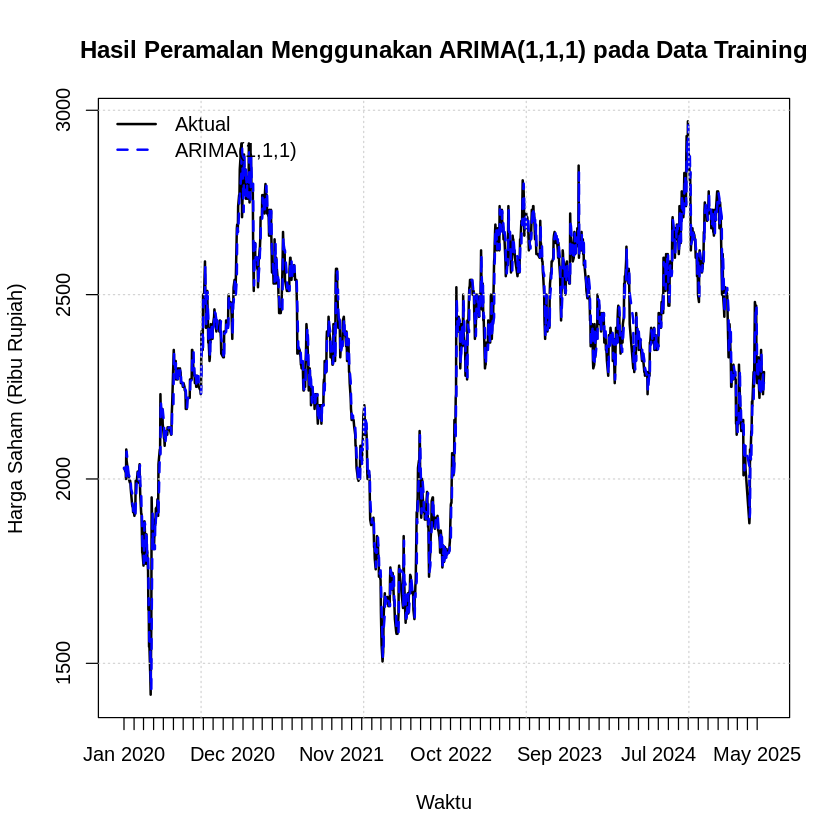

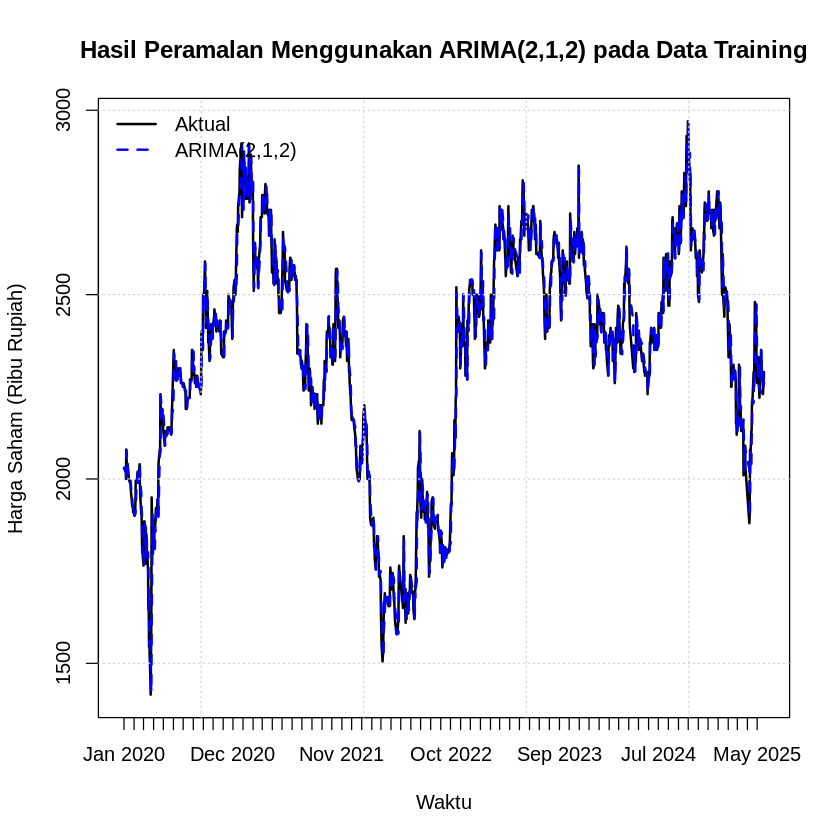

In [ ]:
# ARIMA(0,1,2)
plot(tanggal_train, train, type = "l", col = "black", lwd = 2, lty = 1,
     xlab = "Waktu", ylab = "Harga Saham (Ribu Rupiah)",
     main = "Hasil Peramalan Menggunakan ARIMA(0,1,2) pada Data Training",
     xaxt = "n")
lines(tanggal_train, dugaan1, col = "blue", lty = 2, lwd = 2)
axis.Date(1, at = seq(min(tanggal_train), max(tanggal_train), by = "month"), format = "%b %Y")
grid()
legend("topleft", legend = c("Aktual", "ARIMA(0,1,2)"),
       col = c("black", "blue"), lty = c(1, 2), lwd = 2, bty = "n")

# ARIMA(1,1,1)
plot(tanggal_train, train, type = "l", col = "black", lwd = 2, lty = 1,
     xlab = "Waktu", ylab = "Harga Saham (Ribu Rupiah)",
     main = "Hasil Peramalan Menggunakan ARIMA(1,1,1) pada Data Training",
     xaxt = "n")
lines(tanggal_train, dugaan2, col = "blue", lty = 2, lwd = 2)
axis.Date(1, at = seq(min(tanggal_train), max(tanggal_train), by = "month"), format = "%b %Y")
grid()
legend("topleft", legend = c("Aktual", "ARIMA(1,1,1)"),
       col = c("black", "blue"), lty = c(1, 2), lwd = 2, bty = "n")

# ARIMA(2,1,2)
plot(tanggal_train, train, type = "l", col = "black", lwd = 2, lty = 1,
     xlab = "Waktu", ylab = "Harga Saham (Ribu Rupiah)",
     main = "Hasil Peramalan Menggunakan ARIMA(2,1,2) pada Data Training",
     xaxt = "n")
lines(tanggal_train, dugaan3, col = "blue", lty = 2, lwd = 2)
axis.Date(1, at = seq(min(tanggal_train), max(tanggal_train), by = "month"), format = "%b %Y")
grid()
legend("topleft", legend = c("Aktual", "ARIMA(2,1,2)"),
       col = c("black", "blue"), lty = c(1, 2), lwd = 2, bty = "n")


In [ ]:
#Forecast
fore_arima1<- forecast(train,model=arima1, h=21)

#Forecast
fore_arima2<- forecast(train,model=arima2, h=21)

#Forecast
fore_arima3<- forecast(train,model=arima3, h=21)

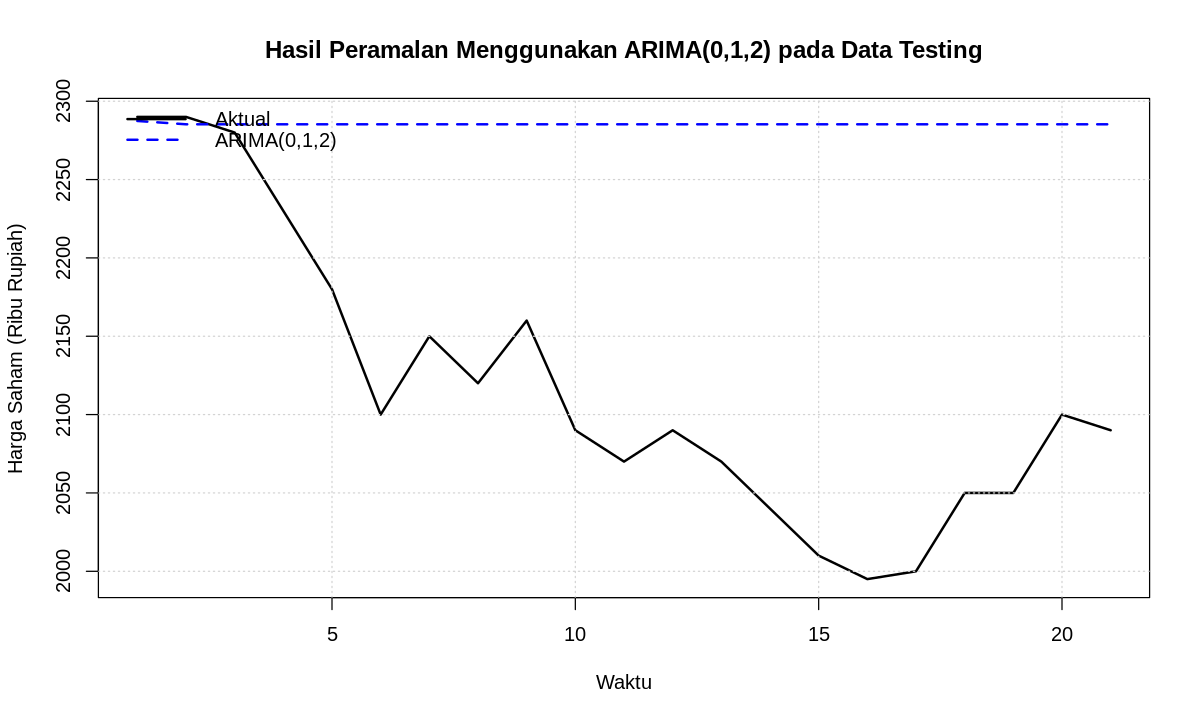

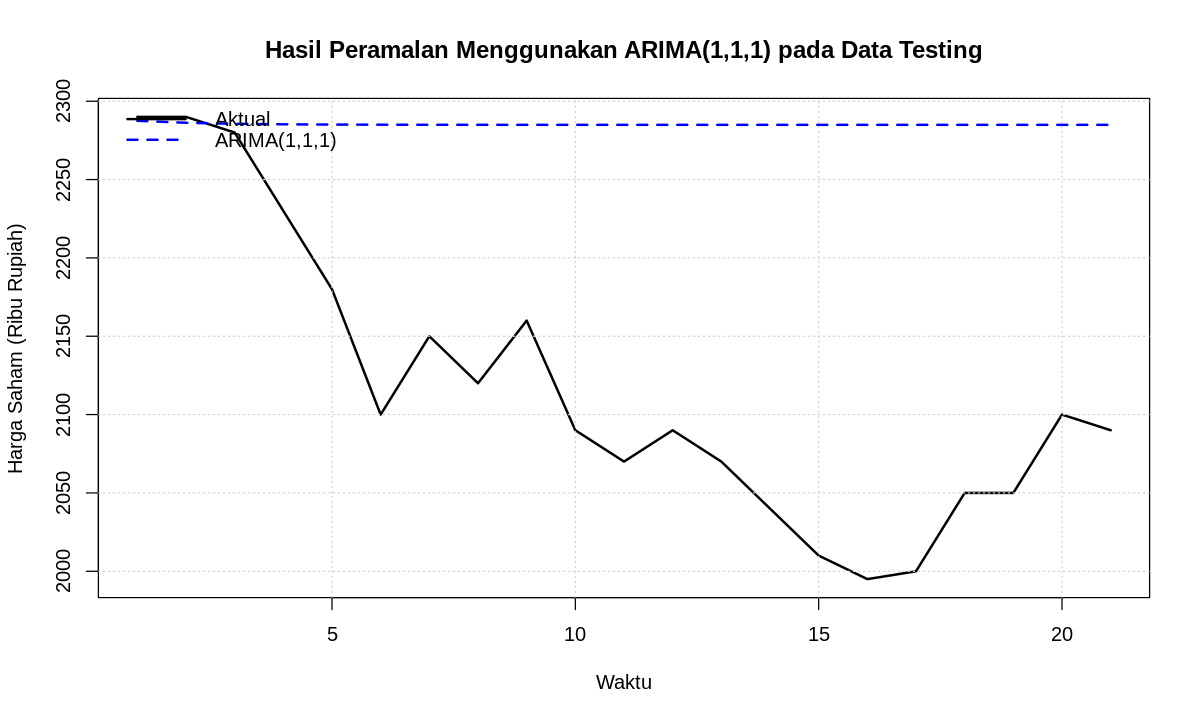

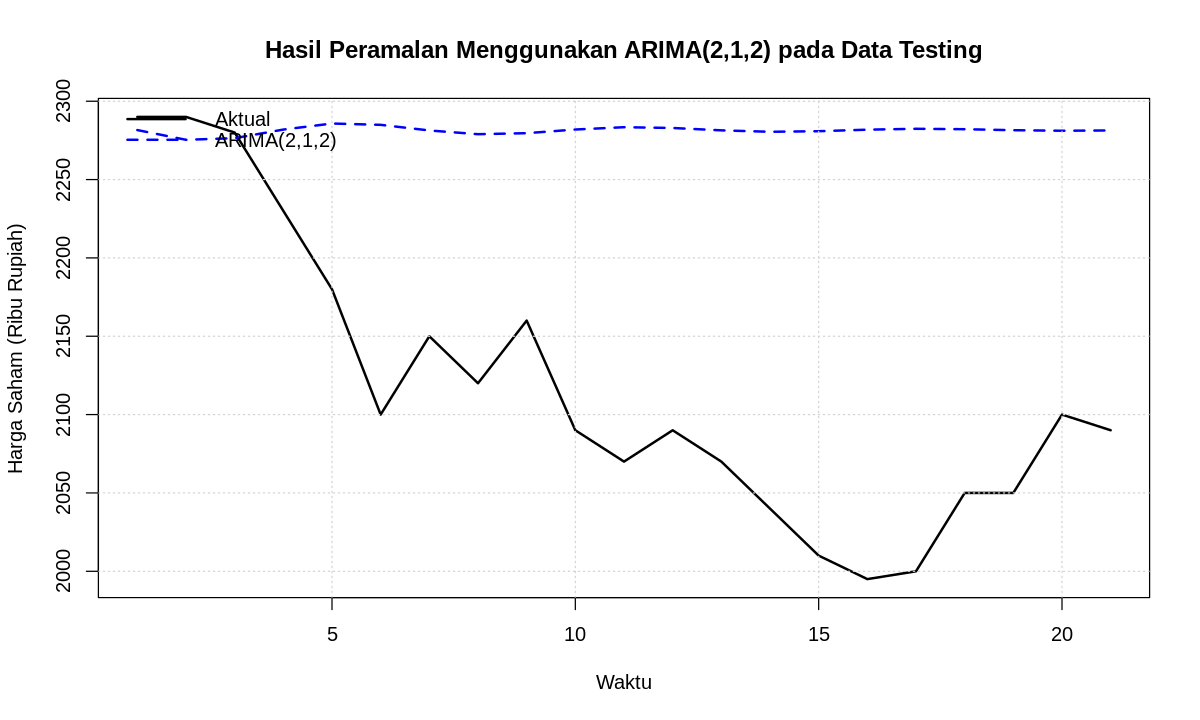

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 6)

# ARIMA(0,1,2)
dugaan1_testing <- ts(fore_arima1$mean)
plot(test, type = "l", col = "black", lwd = 2, lty = 1,
     xlab = "Waktu", ylab = "Harga Saham (Ribu Rupiah)",
     main = "Hasil Peramalan Menggunakan ARIMA(0,1,2) pada Data Testing")
lines(dugaan1_testing, col = "blue", lty = 2, lwd = 2)
grid()
legend("topleft",
       legend = c("Aktual", "ARIMA(0,1,2)"),
       col = c("black", "blue"),
       lty = c(1, 2),
       lwd = 2,
       bty = "n")

# ARIMA(1,1,1)
dugaan2_testing <- ts(fore_arima2$mean)
plot(test, type = "l", col = "black", lwd = 2, lty = 1,
     xlab = "Waktu", ylab = "Harga Saham (Ribu Rupiah)",
     main = "Hasil Peramalan Menggunakan ARIMA(1,1,1) pada Data Testing")
lines(dugaan2_testing, col = "blue", lty = 2, lwd = 2)
grid()
legend("topleft",
       legend = c("Aktual", "ARIMA(1,1,1)"),
       col = c("black", "blue"),
       lty = c(1, 2),
       lwd = 2,
       bty = "n")

# ARIMA(2,1,2)
dugaan3_testing <- ts(fore_arima3$mean)
plot(test, type = "l", col = "black", lwd = 2, lty = 1,
     xlab = "Waktu", ylab = "Harga Saham (Ribu Rupiah)",
     main = "Hasil Peramalan Menggunakan ARIMA(2,1,2) pada Data Testing")
lines(dugaan3_testing, col = "blue", lty = 2, lwd = 2)
grid()
legend("topleft",
       legend = c("Aktual", "ARIMA(2,1,2)"),
       col = c("black", "blue"),
       lty = c(1, 2),
       lwd = 2,
       bty = "n")

**Evaluasi Model**

In [ ]:
pred1_train <- as.numeric(fitted(arima1))
pred2_train <- as.numeric(fitted(arima2))
pred3_train <- as.numeric(fitted(arima3))

actual_train <- as.numeric(train)

# ARIMA(0,1,2)
mape1_train <- mean(abs((actual_train - pred1_train)/actual_train)) * 100
mad1_train  <- mean(abs(actual_train - pred1_train))
rmse1_train <- sqrt(mean((actual_train - pred1_train)^2))

# ARIMA(1,1,1)
mape2_train <- mean(abs((actual_train - pred2_train)/actual_train)) * 100
mad2_train  <- mean(abs(actual_train - pred2_train))
rmse2_train <- sqrt(mean((actual_train - pred2_train)^2))

# ARIMA(2,1,2)
mape3_train <- mean(abs((actual_train - pred3_train)/actual_train)) * 100
mad3_train  <- mean(abs(actual_train - pred3_train))
rmse3_train <- sqrt(mean((actual_train - pred3_train)^2))


In [ ]:
pred1_test <- as.numeric(fore_arima1$mean)
pred2_test <- as.numeric(fore_arima2$mean)
pred3_test <- as.numeric(fore_arima3$mean)

actual_test <- as.numeric(test)

# ARIMA(0,1,2)
mape1_test <- mean(abs((actual_test - pred1_test)/actual_test)) * 100
mad1_test  <- mean(abs(actual_test - pred1_test))
rmse1_test <- sqrt(mean((actual_test - pred1_test)^2))

# ARIMA(1,1,1)
mape2_test <- mean(abs((actual_test - pred2_test)/actual_test)) * 100
mad2_test  <- mean(abs(actual_test - pred2_test))
rmse2_test <- sqrt(mean((actual_test - pred2_test)^2))

# ARIMA(2,1,2)
mape3_test <- mean(abs((actual_test - pred3_test)/actual_test)) * 100
mad3_test  <- mean(abs(actual_test - pred3_test))
rmse3_test <- sqrt(mean((actual_test - pred3_test)^2))

In [ ]:
cat("\n=== Evaluasi ARIMA(0,1,2) pada Data Training ===\n")
cat(sprintf("MAPE: %.3f%%\nMAD: %.3f\nRMSE: %.3f\n", mape1_train, mad1_train, rmse1_train))
cat("\n=== Evaluasi ARIMA(0,1,2) pada Data Testing ===\n")
cat(sprintf("MAPE: %.3f%%\nMAD: %.3f\nRMSE: %.3f\n", mape1_test, mad1_test, rmse1_test))

cat("\n=== Evaluasi ARIMA(1,1,1) pada Data Training ===\n")
cat(sprintf("MAPE: %.3f%%\nMAD: %.3f\nRMSE: %.3f\n", mape2_train, mad2_train, rmse2_train))
cat("\n=== Evaluasi ARIMA(1,1,1) pada Data Testing ===\n")
cat(sprintf("MAPE: %.3f%%\nMAD: %.3f\nRMSE: %.3f\n", mape2_test, mad2_test, rmse2_test))

cat("\n=== Evaluasi ARIMA(2,1,2) pada Data Training ===\n")
cat(sprintf("MAPE: %.3f%%\nMAD: %.3f\nRMSE: %.3f\n", mape3_train, mad3_train, rmse3_train))
cat("\n=== Evaluasi ARIMA(2,1,2) pada Data Testing ===\n")
cat(sprintf("MAPE: %.3f%%\nMAD: %.3f\nRMSE: %.3f\n", mape3_test, mad3_test, rmse3_test))


=== Evaluasi ARIMA(0,1,2) pada Data Training ===
MAPE: 1.428%
MAD: 32.917
RMSE: 47.895

=== Evaluasi ARIMA(0,1,2) pada Data Testing ===
MAPE: 8.177%
MAD: 169.171
RMSE: 190.680

=== Evaluasi ARIMA(1,1,1) pada Data Training ===
MAPE: 1.427%
MAD: 32.917
RMSE: 47.901

=== Evaluasi ARIMA(1,1,1) pada Data Testing ===
MAPE: 8.162%
MAD: 168.864
RMSE: 190.383

=== Evaluasi ARIMA(2,1,2) pada Data Training ===
MAPE: 1.429%
MAD: 32.963
RMSE: 47.779

=== Evaluasi ARIMA(2,1,2) pada Data Testing ===
MAPE: 8.066%
MAD: 166.930
RMSE: 187.673


# **ARIMA-SVR**

Model ARIMA-SVR dibangun dengan menggunakan residual dari model ARIMA terbaik, yaitu ARIMA(2,1,2), sebagai input data.

**Fit ARIMA**

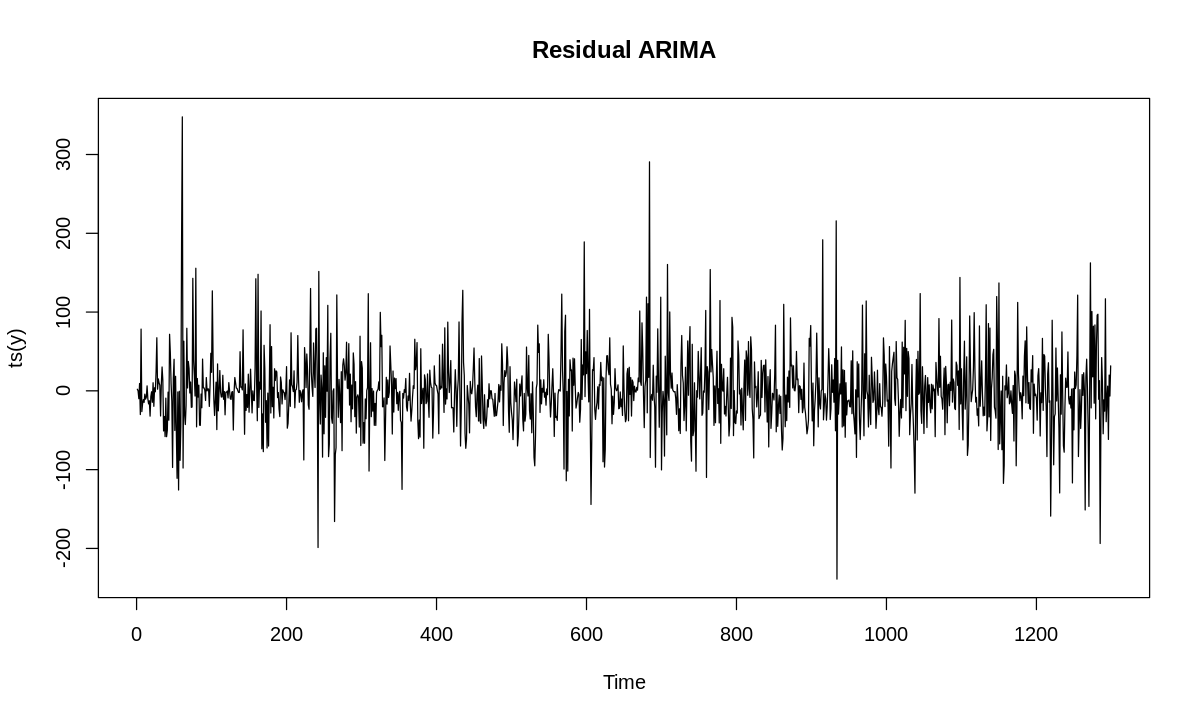

In [ ]:
y <- arima3$residuals
plot(ts(y), main = "Residual ARIMA")

**Standarisasi Residual**

In [ ]:
y_transf <- scale(y)
y_mean <- attr(y_transf, "scaled:center")
y_sd <- attr(y_transf, "scaled:scale")
cat("Rata-rata =", y_mean, "\n")
cat("Std =", y_sd, "\n")


Rata-rata = 0.2143772 
Std = 47.79689 


**Fungsi Bantuan**

In [ ]:
lag_to_supervised <- function(series, lag = 1) {
  n <- length(series)
  df <- embed(series, lag + 1)
  colnames(df) <- c(paste0("lag_", lag:1), "target")
  return(as.data.frame(df))
}

rmse <- function(actual, predicted) {
  sqrt(mean((actual - predicted)^2))
}

**Parameter Grid**

In [ ]:
# ====== DEFINISI GRID ======
kernel_grid <- c("radial", "linear")
lag_grid <- c(1, 2, 3, 4, 5)
cost_grid <- c(0.1, 1, 10, 100, 1000)
epsilon_grid <- c(0.001, 0.01, 0.1, 1)
gamma_grid <- c(0.001, 0.01, 0.1)

# Inisialisasi hasil
results <- data.frame(
  Kernel = character(),
  Lag = integer(),
  Cost = numeric(),
  Epsilon = numeric(),
  Gamma = numeric(),
  RMSE = numeric(),
  stringsAsFactors = FALSE
)

# ====== GRID SEARCH ======
for (kernel in kernel_grid) {
  for (lag in lag_grid) {

    # Buat data supervised
    data_supervised <- lag_to_supervised(y_transf, lag)
    x_train <- data_supervised[, 1:lag]
    y_train <- data_supervised[, lag + 1]

    for (cost in cost_grid) {
      for (epsilon in epsilon_grid) {

        if (kernel == "radial") {
          for (gamma in gamma_grid) {

            svr_model <- svm(
              x = x_train, y = y_train,
              type = "eps-regression",
              kernel = kernel,
              cost = cost,
              epsilon = epsilon,
              gamma = gamma
            )

            y_pred <- predict(svr_model, x_train)
            error <- rmse(y_train, y_pred)

            results <- rbind(
              results,
              data.frame(
                Kernel = kernel,
                Lag = lag,
                Cost = cost,
                Epsilon = epsilon,
                Gamma = gamma,
                RMSE = error,
                stringsAsFactors = FALSE
              )
            )
          }

        } else if (kernel == "linear") {
          # Linear tidak pakai gamma
          svr_model <- svm(
            x = x_train, y = y_train,
            type = "eps-regression",
            kernel = kernel,
            cost = cost,
            epsilon = epsilon
          )

          y_pred <- predict(svr_model, x_train)
          error <- rmse(y_train, y_pred)

          results <- rbind(
            results,
            data.frame(
              Kernel = kernel,
              Lag = lag,
              Cost = cost,
              Epsilon = epsilon,
              Gamma = NA,
              RMSE = error,
              stringsAsFactors = FALSE
            )
          )
        }
      }
    }
  }
}

# ====== HASIL ======
print(results)

best_idx <- which.min(results$RMSE)
best_params <- results[best_idx, ]

cat("\n=== Best Parameters ===\n")
print(best_params)

    Kernel Lag  Cost Epsilon Gamma      RMSE
1   radial   1 1e-01   0.001 0.001 1.0002966
2   radial   1 1e-01   0.001 0.010 1.0001678
3   radial   1 1e-01   0.001 0.100 0.9992164
4   radial   1 1e-01   0.010 0.001 1.0002477
5   radial   1 1e-01   0.010 0.010 1.0000813
6   radial   1 1e-01   0.010 0.100 0.9990480
7   radial   1 1e-01   0.100 0.001 1.0011693
8   radial   1 1e-01   0.100 0.010 1.0011092
9   radial   1 1e-01   0.100 0.100 1.0001540
10  radial   1 1e-01   1.000 0.001 1.0001679
11  radial   1 1e-01   1.000 0.010 1.0001855
12  radial   1 1e-01   1.000 0.100 0.9997500
13  radial   1 1e+00   0.001 0.001 1.0003402
14  radial   1 1e+00   0.001 0.010 0.9995008
15  radial   1 1e+00   0.001 0.100 0.9969508
16  radial   1 1e+00   0.010 0.001 1.0002954
17  radial   1 1e+00   0.010 0.010 0.9996205
18  radial   1 1e+00   0.010 0.100 0.9968854
19  radial   1 1e+00   0.100 0.001 1.0012136
20  radial   1 1e+00   0.100 0.010 1.0008521
21  radial   1 1e+00   0.100 0.100 0.9970746
22  radial

In [ ]:
# Siapkan supervised data untuk lag terbaik
data_supervised <- lag_to_supervised(y_transf, best_params$Lag)
x_train <- data_supervised[, 1:best_params$Lag]
y_train <- data_supervised[, best_params$Lag + 1]

# Build ulang model SVR terbaik
if (best_params$Kernel == "radial") {
  svr_best <- svm(x = x_train, y = y_train,
                  type = "eps-regression",
                  kernel = best_params$Kernel,
                  cost = best_params$Cost,
                  epsilon = best_params$Epsilon,
                  gamma = best_params$Gamma)
} else if (best_params$Kernel == "linear") {
  svr_best <- svm(x = x_train, y = y_train,
                  type = "eps-regression",
                  kernel = best_params$Kernel,
                  cost = best_params$Cost,
                  epsilon = best_params$Epsilon)
}


**Prediksi**

RMSE = 47.83025 
MAE = 33.22333 


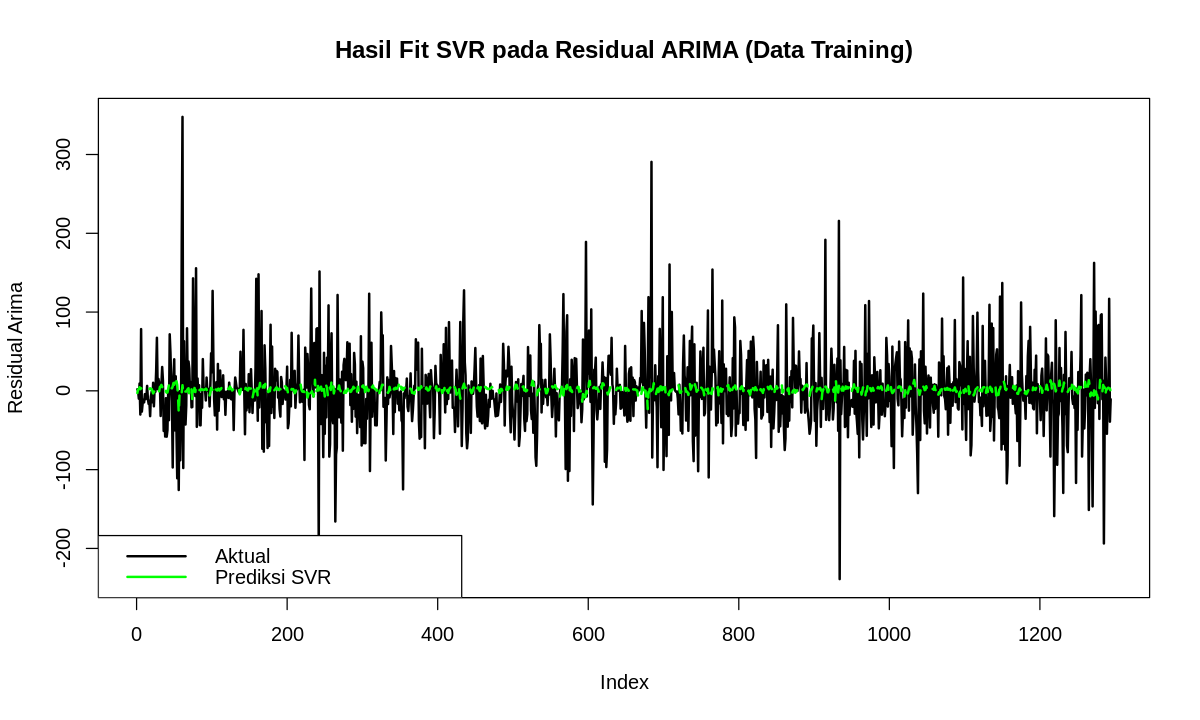

In [ ]:
y_pred_scaled <- predict(svr_model, x_train)
y_pred_original <- y_pred_scaled * y_sd + y_mean
y_true_original <- y_train * y_sd + y_mean

plot(y_true_original, type = "l", col = "black", lwd = 2, ylab = "Residual Arima", main = "Hasil Fit SVR pada Residual ARIMA (Data Training)")
lines(y_pred_original, col = "green", lwd = 2, lty = 2)
legend("bottomleft", legend = c("Aktual", "Prediksi SVR"), col = c("black", "green"), lwd = 2)

rmse_val <- sqrt(mean((y_pred_original - y_true_original)^2))
mae_val <- mean(abs(y_pred_original - y_true_original))
cat("RMSE =", rmse_val, "\n")
cat("MAE =", mae_val, "\n")


**Multistep Forecast**

In [ ]:
# Ambil lag terbaik
best_lag <- best_params$Lag

# Buat data supervised untuk lag terbaik
data_supervised <- lag_to_supervised(y_transf, best_lag)
x_train <- data_supervised[, 1:best_lag]
y_train <- data_supervised[, best_lag + 1]

# Multi-step forecast function
multi_step_forecast <- function(model, last_known, steps) {
  preds_scaled <- numeric(steps)
  current_input <- last_known

  for (i in 1:steps) {
    pred_scaled <- predict(model, as.data.frame(t(current_input)))
    preds_scaled[i] <- pred_scaled
    current_input <- c(current_input[-1], pred_scaled)
  }

  return(preds_scaled)
}

# Siapkan input untuk prediksi
last_known <- tail(y_transf, best_lag)

# Lakukan multi-step forecast
ramal_scaled <- multi_step_forecast(svr_best, last_known, steps = 21)

# Balikkan ke skala asli
ramal <- ramal_scaled * y_sd + y_mean

# Tampilkan hasil
print(ramal)

 [1]  7.275225229 -6.483422424  1.326602265  0.925769442 -3.049315587
 [6] -1.312867166  0.409529926 -0.624639875 -0.679776586  0.088161124
[11] -0.001064939 -0.202743078  0.007903705  0.080942548 -0.008009273
[16]  0.018694332  0.068912635  0.048082593  0.040062049  0.058405085
[21]  0.058440405


**Hybrid Forecast**

Hybrid ARIMA-SVR (Best Model):
RMSE = 187.5467 
MAE  = 166.6356 
MAPE = 8.052753 %
Bias (intercept): 0.843887


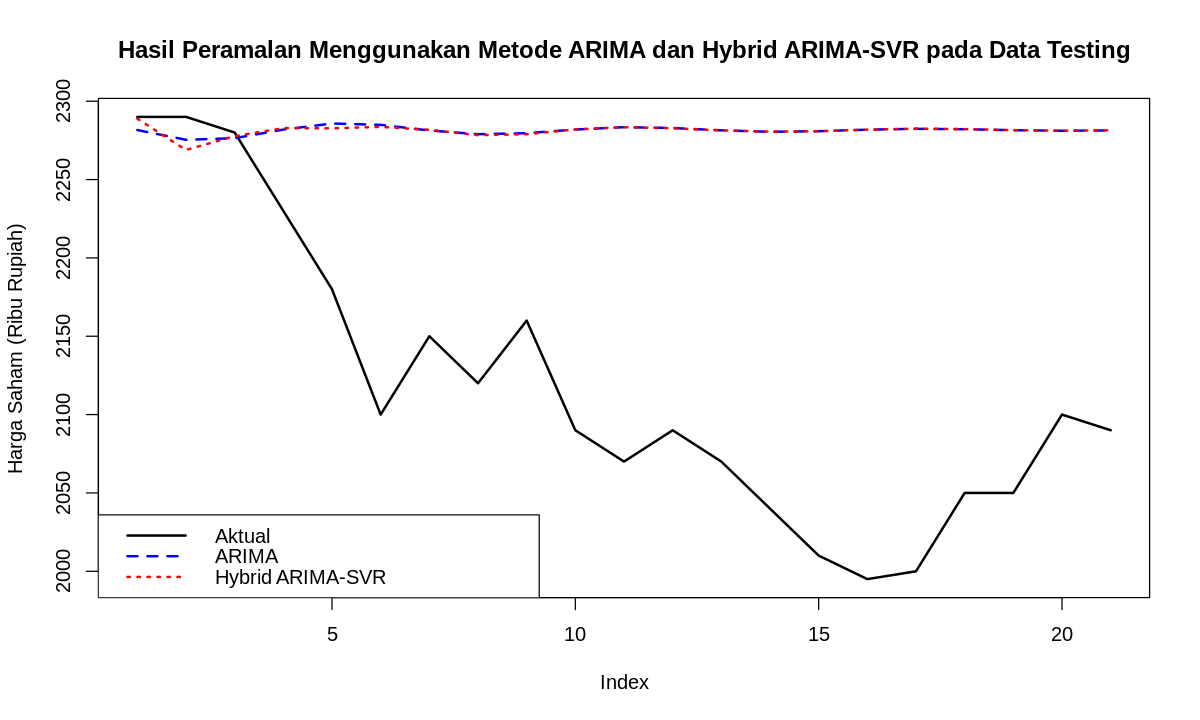

In [ ]:
forecast_arima <- as.numeric(fore_arima3$mean)
forecast_svr_residual <- ramal
forecast_hybrid <- forecast_arima + forecast_svr_residual

rmse_hybrid <- sqrt(mean((forecast_hybrid - test)^2))
mae_hybrid  <- mean(abs(forecast_hybrid - test))
mape_hybrid <- mean(abs((forecast_hybrid - test) / test)) * 100

cat("Hybrid ARIMA-SVR (Best Model):\n")
cat("RMSE =", rmse_hybrid, "\n")
cat("MAE  =", mae_hybrid, "\n")
cat("MAPE =", mape_hybrid, "%\n")
cat(sprintf("Bias (intercept): %.6f\n", svr_best$rho))

plot(test, type = "l", col = "black", lwd = 2, ylab = "Harga Saham (Ribu Rupiah)", main = "Hasil Peramalan Menggunakan Metode ARIMA dan Hybrid ARIMA-SVR pada Data Testing")
lines(forecast_arima, col = "blue", lwd = 2, lty = 2)
lines(forecast_hybrid, col = "red", lwd = 2, lty = 3)
legend("bottomleft", legend = c("Aktual", "ARIMA", "Hybrid ARIMA-SVR"),
       col = c("black", "blue", "red"), lwd = 2, lty = c(1, 2, 3))

# **SVR**

   Kernel    C Epsilon Gamma      RMSE
57 radial 1000     0.1   0.1 0.1536673
Best Kernel and Parameters (supportvector):
   Kernel    C Epsilon Gamma      RMSE
57 radial 1000     0.1   0.1 0.1536673
Training RMSE: 47.5834, MAPE: 1.4306
Testing RMSE: 39.1152, MAPE: 1.5227
Bias (intercept supportvector): 1.302760


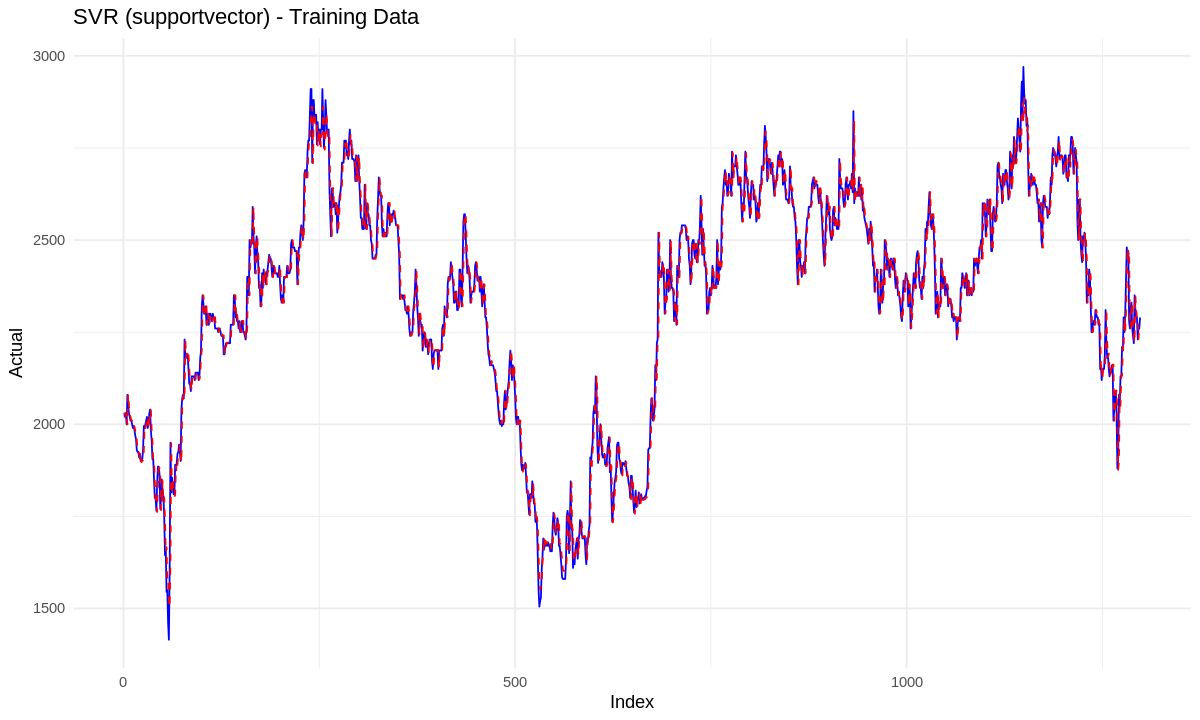

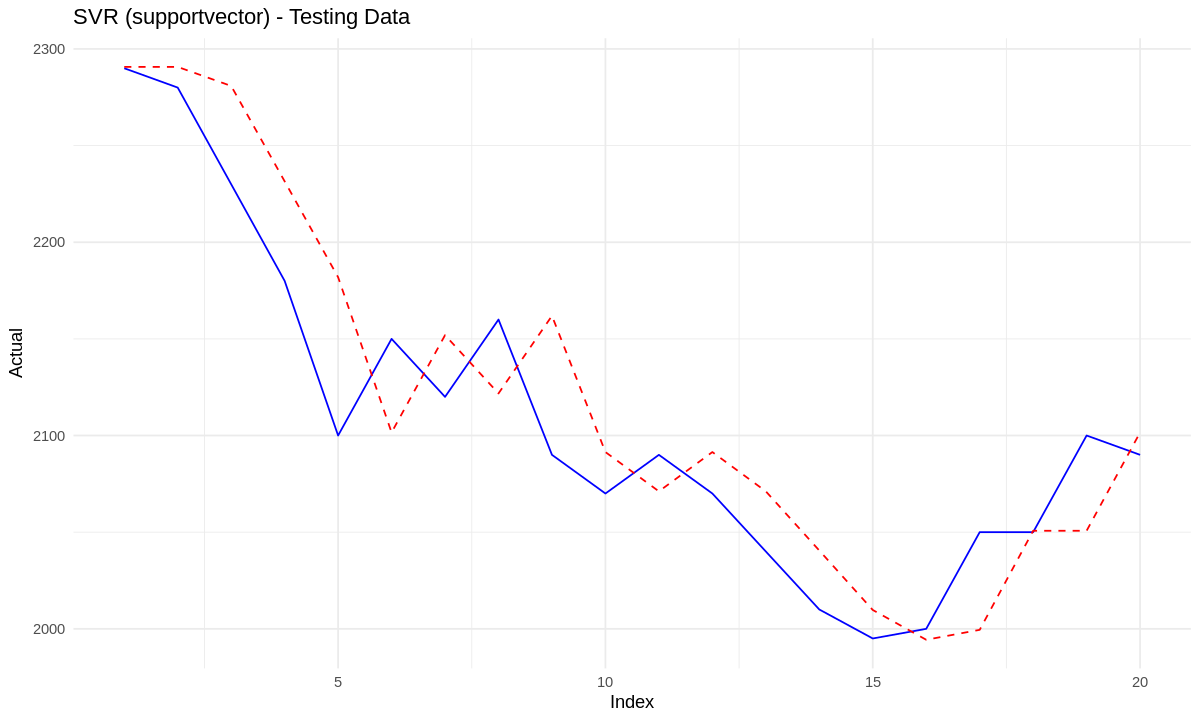

In [ ]:
# === 1. Library ===
library(readxl)
library(e1071)
library(ggplot2)
library(Metrics)

# === 2. Load data ===
datasupportvector_sahammyor <- read_excel("/content/Data Historis MYOR.xlsx")
training_supportvector <- read_excel("/content/trainingMYOR.xlsx")
testing_supportvector <- read_excel("/content/testingMYOR.xlsx")

# === 3. Scaling manual ===
myor_train <- training_supportvector$MYOR
myor_test <- testing_supportvector$MYOR

center_val_supportvector <- mean(myor_train)
scale_val_supportvector <- sd(myor_train)

training_scaled_supportvector <- (myor_train - center_val_supportvector) / scale_val_supportvector
testing_scaled_supportvector <- (myor_test - center_val_supportvector) / scale_val_supportvector

# === 4. Supervised function ===
input_target_supportvector <- function(data, n_lag) {
  X <- embed(data, n_lag + 1)[, -1, drop = FALSE]
  y <- embed(data, n_lag + 1)[, 1]
  X_df <- as.data.frame(X)
  colnames(X_df) <- paste0("lag_", seq_len(ncol(X_df)))
  list(X = X_df, y = y)
}

n_lag_supportvector <- 1
train_supervised_supportvector <- input_target_supportvector(training_scaled_supportvector, n_lag_supportvector)
test_supervised_supportvector <- input_target_supportvector(testing_scaled_supportvector, n_lag_supportvector)

# === 5. Grid search ===
kernel_list <- c("radial", "linear")
C_grid <- c(0.1, 1, 10, 100, 1000)
epsilon_grid <- c(0.001, 0.01, 0.1, 1)
gamma_grid <- c(0.001, 0.01, 0.1)

results_supportvector <- data.frame(
  Kernel = character(),
  C = numeric(),
  Epsilon = numeric(),
  Gamma = numeric(),
  RMSE = numeric(),
  stringsAsFactors = FALSE
)

for (kernel_val in kernel_list) {
  for (C_val in C_grid) {
    for (eps_val in epsilon_grid) {
      if (kernel_val == "radial") {
        for (gamma_val in gamma_grid) {
          model_supportvector <- svm(
            x = train_supervised_supportvector$X,
            y = train_supervised_supportvector$y,
            type = "eps-regression",
            kernel = kernel_val,
            cost = C_val,
            epsilon = eps_val,
            gamma = gamma_val
          )
          pred_train <- predict(model_supportvector, train_supervised_supportvector$X)
          rmse_val <- rmse(train_supervised_supportvector$y, pred_train)

          results_supportvector <- rbind(results_supportvector, data.frame(
            Kernel = kernel_val, C = C_val, Epsilon = eps_val,
            Gamma = gamma_val, RMSE = rmse_val
          ))
        }
      } else {  # linear
        model_supportvector <- svm(
          x = train_supervised_supportvector$X,
          y = train_supervised_supportvector$y,
          type = "eps-regression",
          kernel = kernel_val,
          cost = C_val,
          epsilon = eps_val
        )
        pred_train <- predict(model_supportvector, train_supervised_supportvector$X)
        rmse_val <- rmse(train_supervised_supportvector$y, pred_train)

        results_supportvector <- rbind(results_supportvector, data.frame(
          Kernel = kernel_val, C = C_val, Epsilon = eps_val,
          Gamma = NA, RMSE = rmse_val
        ))
      }
    }
  }
}

# === 6. Best param
best_row_supportvector <- results_supportvector[which.min(results_supportvector$RMSE), ]
print(best_row_supportvector)

# === 7. Fit ulang best
if (best_row_supportvector$Kernel == "radial") {
  best_model_supportvector <- svm(
    x = train_supervised_supportvector$X,
    y = train_supervised_supportvector$y,
    type = "eps-regression",
    kernel = "radial",
    cost = best_row_supportvector$C,
    epsilon = best_row_supportvector$Epsilon,
    gamma = best_row_supportvector$Gamma
  )
} else {
  best_model_supportvector <- svm(
    x = train_supervised_supportvector$X,
    y = train_supervised_supportvector$y,
    type = "eps-regression",
    kernel = "linear",
    cost = best_row_supportvector$C,
    epsilon = best_row_supportvector$Epsilon
  )
}

# === 8. Prediksi
y_train_pred_supportvector <- predict(best_model_supportvector, train_supervised_supportvector$X)
y_test_pred_supportvector <- predict(best_model_supportvector, test_supervised_supportvector$X)

# === 9. Scaling balik
y_train_inv_supportvector <- train_supervised_supportvector$y * scale_val_supportvector + center_val_supportvector
y_train_pred_inv_supportvector <- y_train_pred_supportvector * scale_val_supportvector + center_val_supportvector
y_test_inv_supportvector <- test_supervised_supportvector$y * scale_val_supportvector + center_val_supportvector
y_test_pred_inv_supportvector <- y_test_pred_supportvector * scale_val_supportvector + center_val_supportvector

# === 10. Evaluasi
rmse_train_supportvector <- rmse(y_train_inv_supportvector, y_train_pred_inv_supportvector)
mape_train_supportvector <- mape(y_train_inv_supportvector, y_train_pred_inv_supportvector) * 100
rmse_test_supportvector <- rmse(y_test_inv_supportvector, y_test_pred_inv_supportvector)
mape_test_supportvector <- mape(y_test_inv_supportvector, y_test_pred_inv_supportvector) * 100

cat("Best Kernel and Parameters (supportvector):\n")
print(best_row_supportvector)
cat(sprintf("Training RMSE: %.4f, MAPE: %.4f\n", rmse_train_supportvector, mape_train_supportvector))
cat(sprintf("Testing RMSE: %.4f, MAPE: %.4f\n", rmse_test_supportvector, mape_test_supportvector))
cat(sprintf("Bias (intercept supportvector): %.6f\n", best_model_supportvector$rho))

# === 11. Plot
train_df_supportvector <- data.frame(Index = seq_along(y_train_inv_supportvector),
                                     Actual = y_train_inv_supportvector,
                                     Predicted = y_train_pred_inv_supportvector)

ggplot(train_df_supportvector, aes(x = Index)) +
  geom_line(aes(y = Actual), color = "blue") +
  geom_line(aes(y = Predicted), color = "red", linetype = "dashed") +
  ggtitle("SVR (supportvector) - Training Data") +
  theme_minimal()

test_df_supportvector <- data.frame(Index = seq_along(y_test_inv_supportvector),
                                    Actual = y_test_inv_supportvector,
                                    Predicted = y_test_pred_inv_supportvector)

ggplot(test_df_supportvector, aes(x = Index)) +
  geom_line(aes(y = Actual), color = "blue") +
  geom_line(aes(y = Predicted), color = "red", linetype = "dashed") +
  ggtitle("SVR (supportvector) - Testing Data") +
  theme_minimal()


# **Data Aktual dan Hasil Prediksi pada Data Testing**

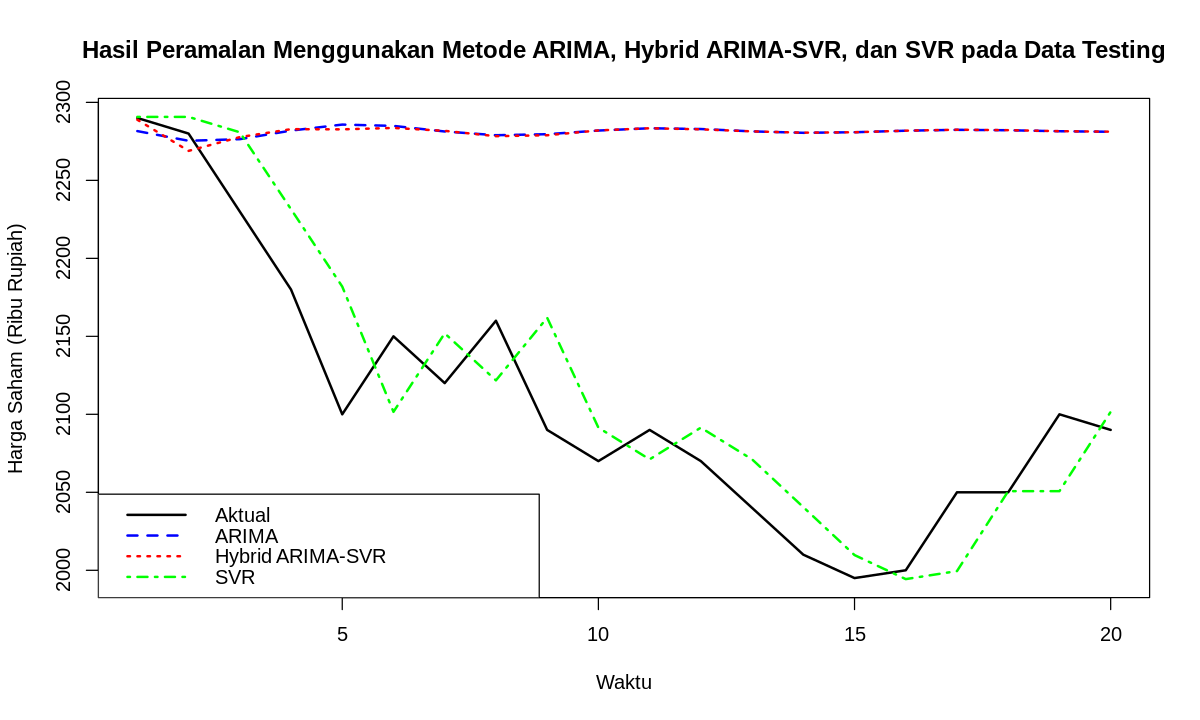

In [ ]:
# === 1. Siapkan DataFrame Hasil ===

# Ambil hanya 20 data pertama biar match dengan SVR dan Aktual
results_df <- data.frame(
  Index = 1:20,
  Aktual = y_test_inv_supportvector,
  ARIMA = forecast_arima[1:20],
  Hybrid = forecast_hybrid[1:20],
  SVR = y_test_pred_inv_supportvector
)

# === 2. Plot ===

plot(results_df$Index, results_df$Aktual, type = "l", col = "black", lwd = 2,
     ylab = "Harga Saham (Ribu Rupiah)", xlab = "Waktu",
     main = "Hasil Peramalan Menggunakan Metode ARIMA, Hybrid ARIMA-SVR, dan SVR pada Data Testing",
     ylim = range(c(results_df$Aktual, results_df$ARIMA, results_df$Hybrid, results_df$SVR), na.rm = TRUE))

lines(results_df$Index, results_df$ARIMA, col = "blue", lwd = 2, lty = 2)
lines(results_df$Index, results_df$Hybrid, col = "red", lwd = 2, lty = 3)
lines(results_df$Index, results_df$SVR, col = "green", lwd = 2, lty = 4)

legend("bottomleft", legend = c("Aktual", "ARIMA", "Hybrid ARIMA-SVR", "SVR"),
       col = c("black", "blue", "red", "green"),
       lwd = 2, lty = c(1, 2, 3, 4))


In [ ]:
cat("Evaluasi ARIMA(2,1,2) pada Data Testing:\n")
cat(sprintf("MAPE: %.3f%%\n", mape3_test))

cat("Evaluasi Hybrid ARIMA-SVR pada Data Testing:\n")
cat(sprintf("MAPE: %.3f%%\n", mape_hybrid))

cat("Evaluasi SVR pada Data Testing:\n")
cat(sprintf("MAPE: %.3f%%\n", mape_test_supportvector))


Evaluasi ARIMA(2,1,2) pada Data Testing:
MAPE: 8.066%
Evaluasi Hybrid ARIMA-SVR pada Data Testing:
MAPE: 8.053%
Evaluasi SVR pada Data Testing:
MAPE: 1.523%
